# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Import the libraries you will be using for analysis
import pandas as pd         #data processing
import numpy as np          #linear algebra 

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#date & time
import datetime as dt
#Geo Location
import geopandas as gpd
import os
#garbage Collector
import gc 

In [6]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.4.0
pandas version: 2.3.3
matplotlib version: 3.11.2
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [7]:
# Try loading one file

df = pd.read_parquet(r'D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\trip_records\2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [8]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload
df.sample(frac=0.05, random_state=42)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
323412,1,2023-01-05 07:50:08,2023-01-05 08:02:04,2.0,1.90,1.0,N,239,236,1,13.5,2.5,0.5,2.50,0.00,1.0,20.00,2.5,0.00
1491266,2,2023-01-17 07:47:24,2023-01-17 08:00:50,5.0,1.86,1.0,N,239,162,1,14.2,0.0,0.5,3.64,0.00,1.0,21.84,2.5,0.00
2385670,2,2023-01-25 21:57:59,2023-01-25 22:00:33,1.0,0.50,1.0,N,162,170,1,5.1,1.0,0.5,2.02,0.00,1.0,12.12,2.5,0.00
766545,2,2023-01-09 19:36:54,2023-01-09 19:52:01,2.0,2.56,1.0,N,162,262,1,17.0,2.5,0.5,4.70,0.00,1.0,28.20,2.5,0.00
980153,1,2023-01-11 22:19:13,2023-01-11 22:32:37,1.0,2.80,1.0,N,164,231,1,14.9,3.5,0.5,3.98,0.00,1.0,23.88,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458862,2,2023-01-26 16:36:18,2023-01-26 16:42:36,1.0,0.96,1.0,N,226,260,2,7.9,2.5,0.5,0.00,0.00,1.0,11.90,0.0,0.00
1685425,1,2023-01-18 23:17:20,2023-01-18 23:22:57,1.0,1.30,1.0,N,239,238,1,8.6,3.5,0.5,2.70,0.00,1.0,16.30,2.5,0.00
726902,2,2023-01-09 12:50:57,2023-01-09 13:13:26,2.0,8.69,1.0,N,138,247,1,37.3,5.0,0.5,10.07,6.55,1.0,61.67,0.0,1.25
958184,2,2023-01-11 19:42:23,2023-01-11 20:09:57,2.0,17.40,2.0,N,132,170,1,70.0,5.0,0.5,5.00,6.55,1.0,90.55,2.5,0.00


In [21]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
data_path = r'D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\trip_records'

In [10]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(data_path)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_data = pd.read_parquet(file_path)

        # Convert pickup datetime to datetime format
        month_data['tpep_pickup_datetime'] = pd.to_datetime(
        month_data['tpep_pickup_datetime']
        )

        # Create date and hour columns
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_data['pickup_date'].unique():
            date_data = month_data[month_data['pickup_date'] == date]
            # Iterate through each hour of the selected date
            for hour in range(24):
                hour_data = date_data[date_data['pickup_hour'] == hour]
                # Sample 5% of the hourly data randomly
                if len(hour_data) > 0:
                    sample = hour_data.sample(frac=0.05, random_state=42)
                # add data of this hour to the dataframe
                    sampled_data = pd.concat([sampled_data, sample], ignore_index=True )
        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat( [df, sampled_data], ignore_index=True ) # we initialised this empty DF earlier
        print(
            f"{file_name}: {len(month_data):,} rows → "
            f"{len(sampled_data):,} sampled rows"
        )

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

2023-1.parquet: 3,041,714 rows → 152,087 sampled rows
2023-10.parquet: 3,485,185 rows → 174,255 sampled rows
2023-11.parquet: 3,302,857 rows → 165,133 sampled rows
2023-12.parquet: 3,333,925 rows → 166,709 sampled rows
2023-2.parquet: 3,374,086 rows → 168,696 sampled rows
2023-3.parquet: 3,275,796 rows → 163,786 sampled rows
2023-4.parquet: 2,792,901 rows → 139,641 sampled rows
2023-5.parquet: 2,889,185 rows → 144,458 sampled rows
2023-6.parquet: 3,258,261 rows → 162,910 sampled rows
2023-7.parquet: 3,481,547 rows → 174,068 sampled rows
2023-8.parquet: 2,875,947 rows → 143,782 sampled rows
2023-9.parquet: 2,817,156 rows → 140,875 sampled rows


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [11]:
# Store the df in csv/parquet
final_file = r'D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\sampled_nyc_taxi_2023_file.parquet'
df.to_parquet(final_file, index=False)
print("File saved successfully!")
print("Location:", final_file)
print("Shape:", df.shape)

File saved successfully!
Location: D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\sampled_nyc_taxi_2023_file.parquet
Shape: (1896400, 22)


In [12]:
### The sampling fraction provided still gave a large dataset. Adjusting it to 300,000 records
if len(df) > 300000:
    df = df.sample(n=300000, random_state=42)
else:
    df = df.groupby(df['tpep_pickup_datetime'].dt.hour, group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

In [13]:
# Store the df in csv/parquet
main_file = r'D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\final_nyc_taxi_2023_file.parquet'
df.to_parquet(main_file, index=False)
print("File saved successfully!")
print("Location:", main_file)
print("Shape:", df.shape)

File saved successfully!
Location: D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\final_nyc_taxi_2023_file.parquet
Shape: (300000, 22)


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [14]:
# Load the new data file
df = pd.read_parquet(r'D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\3lacs_records_nyc_taxi_2023_final_file.parquet')


In [15]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,N,24,141,1,...,0.5,5.50,0.00,1.0,27.50,2.5,NaN,2023-04-21,1,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,N,186,170,2,...,0.5,0.00,0.00,1.0,14.00,2.5,0.0,2023-01-10,14,NaN
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,N,132,151,1,...,0.5,10.00,6.55,1.0,89.30,0.0,NaN,2023-02-04,15,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,N,186,239,1,...,0.5,5.46,0.00,1.0,32.76,2.5,NaN,2023-03-24,12,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,N,142,237,1,...,0.5,3.58,0.00,1.0,21.48,2.5,NaN,2023-09-05,17,0.00


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289777 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289777 non-null  float64       
 6   store_and_fwd_flag     289777 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [17]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
df.drop(columns = ['store_and_fwd_flag'], inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289777 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289777 non-null  float64       
 6   PULocationID           300000 non-null  int64         
 7   DOLocationID           300000 non-null  int64         
 8   payment_type           300000 non-null  int64         
 9   fare_amount            300000 non-null  float64       
 10  extra                  300000 non-null  float64       
 11  mta_tax                300000 non-null  float64       
 12  tip_amount             300000 non-null  floa

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [20]:
# Combine the two airport fee columns
# Checking the columns values of both the airport columns
print(df[['airport_fee', 'Airport_fee']].info())

print("\nMissing values:")
print(df[['airport_fee', 'Airport_fee']].isnull().sum())

print("\nFirst 10 rows:")
print(df[['airport_fee', 'Airport_fee']].head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   airport_fee  23260 non-null   float64
 1   Airport_fee  266517 non-null  float64
dtypes: float64(2)
memory usage: 4.6 MB
None

Missing values:
airport_fee    276740
Airport_fee     33483
dtype: int64

First 10 rows:
   airport_fee  Airport_fee
0          NaN         0.00
1          0.0          NaN
2          NaN         1.25
3          NaN         0.00
4          NaN         0.00
5          NaN         0.00
6          0.0          NaN
7          NaN         0.00
8          NaN         0.00
9          NaN         0.00


In [21]:
# Check rows where both columns have values
both_present = df[['airport_fee', 'Airport_fee']].dropna()

print("Rows where both have values:", len(both_present))
print("Different values:", 
      (both_present['airport_fee'] != both_present['Airport_fee']).sum())

Rows where both have values: 0
Different values: 0


In [22]:
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])
df.drop(columns=['Airport_fee'], inplace=True)
df['airport_fee'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 300000 entries, 0 to 299999
Series name: airport_fee
Non-Null Count   Dtype  
--------------   -----  
289777 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


In [23]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour'],
      dtype='object')

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [24]:
# check where values of fare amount are negative
negative_fare = df[df['fare_amount'] < 0]

print("Number of negative fare_amount records:", len(negative_fare))

negative_fare[
    ['RatecodeID', 'fare_amount', 'total_amount']
]

Number of negative fare_amount records: 0


,RatecodeID,fare_amount,total_amount


In [25]:
# checking negative columns values
monetary_columns = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

In [26]:
negative_counts = (df[monetary_columns] < 0).sum()

print("Negative values by column:")
print(negative_counts)


Negative values by column:
fare_amount               0
extra                     0
mta_tax                  15
tip_amount                0
tolls_amount              0
improvement_surcharge    16
total_amount             16
congestion_surcharge     14
airport_fee               3
dtype: int64


In [27]:
print(
    negative_counts[negative_counts > 0]
)

mta_tax                  15
improvement_surcharge    16
total_amount             16
congestion_surcharge     14
airport_fee               3
dtype: int64


Did you notice something different in the `RatecodeID` column for above records?

In [28]:
# Analyse RatecodeID for the negative fare amounts

print("RatecodeID distribution for negative fare records:")

print(
    negative_fare['RatecodeID'].value_counts(dropna=False)
)

RatecodeID distribution for negative fare records:
Series([], Name: count, dtype: int64)


In [29]:
negative_fare

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour


In [30]:
# Find which columns have negative values

print(
    negative_counts[negative_counts > 0]
)


mta_tax                  15
improvement_surcharge    16
total_amount             16
congestion_surcharge     14
airport_fee               3
dtype: int64


In [31]:
# fix these negative values
df = df[
    (df[monetary_columns] >= 0).all(axis=1)
].copy()

print("Negative values after cleaning:")

for col in monetary_columns:
    print(
        f"{col}: {(df[col] < 0).sum()} negative values"
    )

Negative values after cleaning:
fare_amount: 0 negative values
extra: 0 negative values
mta_tax: 0 negative values
tip_amount: 0 negative values
tolls_amount: 0 negative values
improvement_surcharge: 0 negative values
total_amount: 0 negative values
congestion_surcharge: 0 negative values
airport_fee: 0 negative values


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [32]:
# Find the proportion of missing values in each column

missing_proportion = df.isnull().mean() * 100
print("Percentage of missing values in each column:")
print(missing_proportion)

Percentage of missing values in each column:
VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
RatecodeID               0.0
PULocationID             0.0
DOLocationID             0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
congestion_surcharge     0.0
airport_fee              0.0
pickup_date              0.0
pickup_hour              0.0
dtype: float64


In [33]:
#This shows no columns are having null values

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [34]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

passenger_null = df[df['passenger_count'].isnull()]

print("Number of missing passenger_count values:",
      len(passenger_null))


Number of missing passenger_count values: 0


In [35]:
# this shows that there is no rows with passenger value null

Did you find zeroes in passenger_count? Handle these.

In [36]:
zero_passengers = (df['passenger_count'] == 0).sum()

print("Number of passenger_count = 0:", zero_passengers)

Number of passenger_count = 0: 4635


In [37]:
df[df['passenger_count'] == 0][
    ['passenger_count',
     'trip_distance',
     'fare_amount',
     'total_amount']
].head(20)

,passenger_count,trip_distance,fare_amount,total_amount
35,0.0,2.4,15.6,26.50
56,0.0,2.9,14.2,22.20
112,0.0,15.6,70.0,100.30
220,0.0,4.1,28.2,41.70
271,0.0,16.8,70.0,87.69
277,0.0,2.6,19.1,27.72
317,0.0,0.6,10.7,17.60
356,0.0,1.7,15.6,19.60
443,0.0,6.6,31.0,42.00
452,0.0,1.4,10.0,17.00


In [38]:
passenger_median = df['passenger_count'].median()

df['passenger_count'] = df['passenger_count'].fillna(
    passenger_median
)

print("Median passenger_count used for imputation:",
      passenger_median)

Median passenger_count used for imputation: 1.0


In [39]:
# Replace zero passenger_count values with median

df.loc[
    df['passenger_count'] == 0,
    'passenger_count'
] = passenger_median

In [40]:
print(
    "Missing passenger_count:",
    df['passenger_count'].isnull().sum()
)

print(
    "Zero passenger_count:",
    (df['passenger_count'] == 0).sum()
)

Missing passenger_count: 0
Zero passenger_count: 0


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [41]:
# Fix missing values in 'RatecodeID'
print(
    "Missing RatecodeID:",
    df['RatecodeID'].isnull().sum()
)


Missing RatecodeID: 0


In [42]:
print(
    df['RatecodeID'].value_counts(dropna=False).sort_index()
)

RatecodeID
1.0     273508
2.0      11350
3.0        982
4.0        630
5.0       1609
6.0          1
99.0      1681
Name: count, dtype: int64


In [43]:
ratecode_mode = df['RatecodeID'].mode()[0]

df['RatecodeID'] = df['RatecodeID'].fillna(
    ratecode_mode
)

print("RatecodeID mode used for imputation:",
      ratecode_mode)

RatecodeID mode used for imputation: 1.0


In [44]:
print(
    "Missing RatecodeID after imputation:",
    df['RatecodeID'].isnull().sum()
)

Missing RatecodeID after imputation: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [45]:
# handle null values in congestion_surcharge
print(
    "Missing congestion_surcharge:",
    df['congestion_surcharge'].isnull().sum()
)

Missing congestion_surcharge: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [46]:
# Handle any remaining missing values
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
pickup_date              0
pickup_hour              0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [47]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,289761.000000,289761,289761,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000,289761.000000
mean,1.737228,2023-07-02 01:25:06.029038,2023-07-02 01:42:26.845689,1.386305,3.478110,1.643230,165.394411,164.431970,1.205397,19.738008,1.634651,0.495284,3.574402,0.590303,0.999218,28.854183,2.307065,0.142884,14.283282
min,1.000000,2023-01-01 00:04:55,2023-01-01 00:10:20,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 01:25:10,2023-04-02 01:40:37,1.000000,1.050000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000
50%,2.000000,2023-06-26 10:05:30,2023-06-26 10:26:30,1.000000,1.780000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.860000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000
75%,2.000000,2023-10-05 21:19:01,2023-10-05 21:39:54,1.000000,3.370000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.700000,2.500000,0.000000,19.000000
max,2.000000,2023-12-31 23:45:46,2024-01-01 00:15:03,8.000000,9678.340000,99.000000,265.000000,265.000000,4.000000,999.000000,11.750000,0.800000,200.000000,87.500000,1.000000,1000.000000,2.500000,1.750000,23.000000
std,0.440140,NaN,NaN,0.877609,18.588696,7.447394,63.811401,69.741321,0.465617,18.493138,1.835361,0.048453,4.139319,2.169967,0.025964,23.078804,0.667169,0.464874,5.787388


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [48]:
# remove passenger_count > 6
# Checking passenger counts greater than 6

print(
    "Passenger counts > 6:",
    (df['passenger_count'] > 6).sum()
)

print(
    df.loc[df['passenger_count'] > 6, 'passenger_count']
    .value_counts()
)

Passenger counts > 6: 1
passenger_count
8.0    1
Name: count, dtype: int64


In [49]:
# Remove passenger_count > 6

df = df[df['passenger_count'] <= 6].copy()

print("Shape after removing passenger_count > 6:", df.shape)


Shape after removing passenger_count > 6: (289760, 20)


In [50]:
#Entries where trip_distance is nearly 0 and fare_amount is more than 300
zero_distance_high_fare = df[
    (df['trip_distance'] <= 0.1) &
    (df['fare_amount'] > 300)
]

print(
    "Trips with trip_distance <= 0.1 and fare_amount > 300:",
    len(zero_distance_high_fare)
)

zero_distance_high_fare[
    [
        'trip_distance',
        'fare_amount',
        'total_amount',
        'PULocationID',
        'DOLocationID',
        'payment_type'
    ]
]

Trips with trip_distance <= 0.1 and fare_amount > 300: 9


,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,payment_type
24018,0.0,305.14,367.37,265,265,1
75869,0.0,500.00,501.00,265,265,2
94360,0.0,450.00,450.00,264,264,1
141633,0.0,600.00,601.00,265,265,2
148673,0.0,500.00,501.00,181,181,4
250378,0.0,999.00,1000.00,141,141,3
262731,0.0,500.00,507.55,265,265,4
272900,0.0,500.00,501.00,39,39,3
278198,0.0,350.00,422.95,132,132,1


Note: A trip with almost no recorded distance and a fare above $300 is unlikely to represent a normal taxi trip. ,I would drop these records rather than replace the fare or distance.

In [51]:
df = df[
    ~(
        (df['trip_distance'] <= 0.1) &
        (df['fare_amount'] > 300)
    )
].copy()

Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)

In [52]:
zero_distance_fare_different_zones = df[
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
]

print(
    "Zero distance/fare with different zones:",
    len(zero_distance_fare_different_zones)
)

zero_distance_fare_different_zones[
    [
        'PULocationID',
        'DOLocationID',
        'trip_distance',
        'fare_amount',
        'total_amount'
    ]
].head(20)

Zero distance/fare with different zones: 12


,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount
69381,161,264,0.0,0.0,0.00
75061,132,215,0.0,0.0,2.75
75199,161,119,0.0,0.0,0.00
121973,237,264,0.0,0.0,0.00
133762,265,264,0.0,0.0,0.00
142184,265,264,0.0,0.0,1.00
147819,239,264,0.0,0.0,0.00
151547,138,264,0.0,0.0,0.00
172488,137,227,0.0,0.0,0.00
189326,138,264,0.0,0.0,10.25


Note: These records violate a logical condition, so droping them.

In [53]:
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
].copy()

In [55]:
#Entries where trip_distance is more than 250 miles.

In [56]:
long_trips = df[df['trip_distance'] > 250]

print(
    "Trips with distance > 250 miles:",
    len(long_trips)
)

long_trips[
    [
        'trip_distance',
        'fare_amount',
        'total_amount',
        'PULocationID',
        'DOLocationID'
    ]
].head(20)

Trips with distance > 250 miles: 2


,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID
33246,721.26,7.9,11.40,145,7
99347,9678.34,29.6,48.07,138,197


In [57]:
df = df[df['trip_distance'] <= 250].copy()

Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)

In [58]:
# Check invalid payment_type = 0

invalid_payment = df[df['payment_type'] == 0]

print(
    "Records with payment_type = 0:",
    len(invalid_payment)
)

Records with payment_type = 0: 0


Investigating fare_amount = 999 and total_amount = 1000.

In [59]:
# Continue with outlier handling
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,289737.000000,289737,289737,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000,289737.000000
mean,1.737258,2023-07-02 01:26:12.973127,2023-07-02 01:43:33.832027,1.386299,3.442439,1.642400,165.392245,164.428219,1.205321,19.722995,1.634705,0.495320,3.574159,0.590306,0.999252,28.839193,2.307239,0.142872,14.283271
min,1.000000,2023-01-01 00:04:55,2023-01-01 00:10:20,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 01:28:15,2023-04-02 01:44:47,1.000000,1.050000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000
50%,2.000000,2023-06-26 10:05:54,2023-06-26 10:26:40,1.000000,1.780000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.860000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000
75%,2.000000,2023-10-05 21:19:01,2023-10-05 21:39:54,1.000000,3.380000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.700000,2.500000,0.000000,19.000000
max,2.000000,2023-12-31 23:45:46,2024-01-01 00:15:03,6.000000,172.710000,99.000000,265.000000,265.000000,4.000000,500.000000,11.750000,0.800000,200.000000,87.500000,1.000000,516.690000,2.500000,1.750000,23.000000
std,0.440124,NaN,NaN,0.877547,4.552378,7.443268,63.810882,69.739271,0.465462,18.249417,1.835290,0.048271,4.136089,2.169990,0.025293,22.882168,0.666894,0.464853,5.787461


RatecodeID Has a maximum value as 99, but as per the Data Dictionary we have only 1 to 6 values.

In [60]:
print(df['RatecodeID'].value_counts(dropna=False).sort_index())

RatecodeID
1.0     273501
2.0      11350
3.0        982
4.0        630
5.0       1594
6.0          1
99.0      1679
Name: count, dtype: int64


In [61]:
# Find invalid RatecodeID values

valid_ratecodes = [1, 2, 3, 4, 5, 6]

invalid_ratecode = df[
    ~df['RatecodeID'].isin(valid_ratecodes)
]

print("Invalid RatecodeID records:", len(invalid_ratecode))

print(
    invalid_ratecode['RatecodeID'].value_counts(dropna=False)
)

Invalid RatecodeID records: 1679
RatecodeID
99.0    1679
Name: count, dtype: int64


In [62]:
df = df[
    df['RatecodeID'].isin(valid_ratecodes)
].copy()
print(
    df['RatecodeID'].value_counts(dropna=False).sort_index()
)

RatecodeID
1.0    273501
2.0     11350
3.0       982
4.0       630
5.0      1594
6.0         1
Name: count, dtype: int64


Note:For an outlier/data-quality cleaning step, dropping records with an invalid RatecodeID is defensible

In [63]:
# Do any columns need standardising?
# Note: No blanket standardization is required at the data-cleaning stage; categorical/code columns should not be treated as continuous numerical variables.


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [67]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_date',
 'pickup_hour',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Categorical
* `tpep_dropoff_datetime`: Categorical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

Numerical

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
# create column pickup_hour and trip_duration
# Convert datetime columns
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
# Create required time-based columns
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

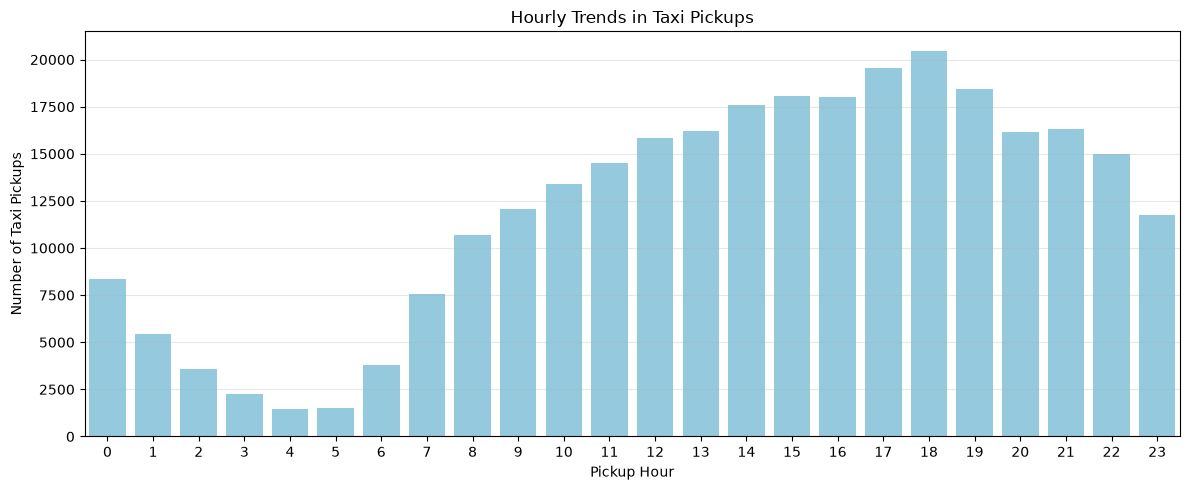

In [71]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='pickup_hour', color='skyblue')

plt.title('Hourly Trends in Taxi Pickups')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Taxi Pickups')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Hourly Trends In Taxi Pickups.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()


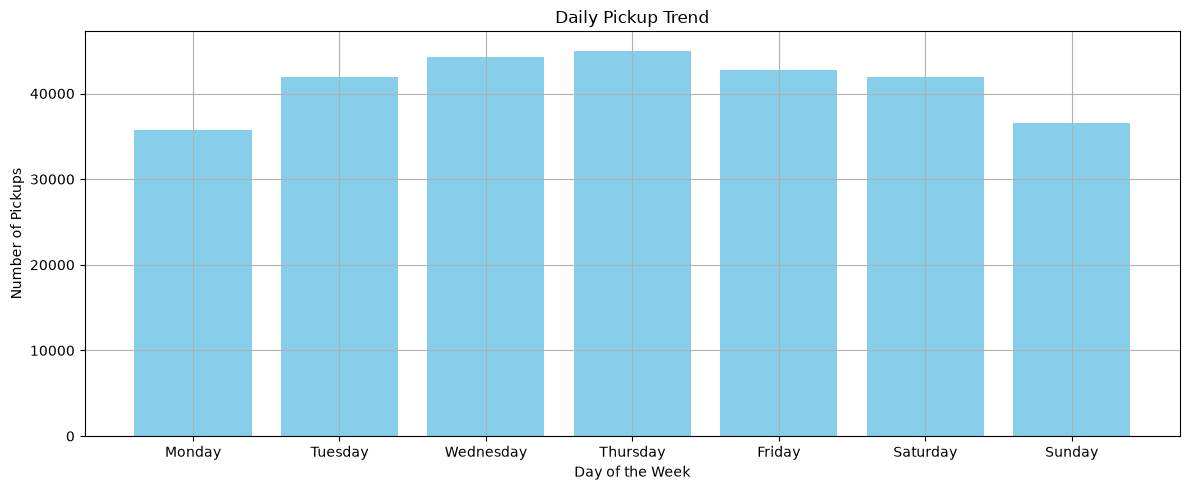

In [72]:
# Find and show the daily trends in taxi pickups (days of the week)
# lets add one column for week_Day
df['week_Day']=df['tpep_pickup_datetime'].dt.dayofweek
#lets consider as a set
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_name'] = df['week_Day'].map(day_names)

daily_pickups = df.groupby('day_name').size().reindex(day_names.values()).reset_index(name='pickup_count')

plt.figure(figsize=(12, 5))
plt.bar(daily_pickups['day_name'], daily_pickups['pickup_count'], color='skyblue')
plt.title('Daily Pickup Trend')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.grid(True)
plt.tight_layout()
plt.savefig(
    'Daily Trends In Taxi Pickups.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

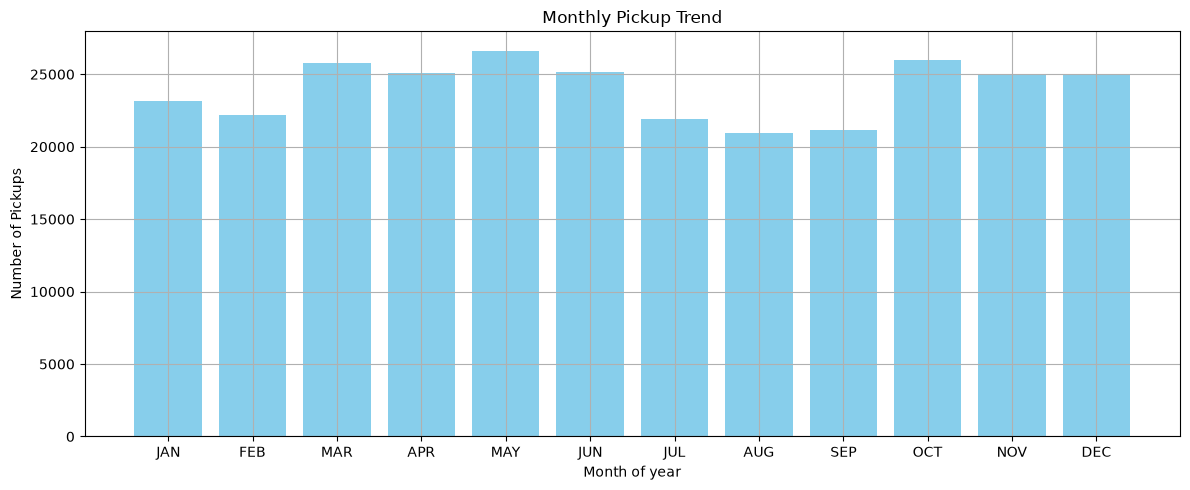

In [73]:
# Show the monthly trends in pickups
df['Month']=df['tpep_pickup_datetime'].dt.month
months_ = {1: 'JAN', 2: 'FEB', 3: 'MAR', 4: 'APR', 5: 'MAY', 6: 'JUN', 7: 'JUL', 8: 'AUG', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DEC' }
df['Month_name']=df['Month'].map(months_)
monthly_trend=df.groupby('Month_name').size().reindex(months_.values()).reset_index(name='pickup_count')
plt.figure(figsize=(12, 5))
plt.bar(monthly_trend['Month_name'], monthly_trend['pickup_count'], color='skyblue')
plt.title('Monthly Pickup Trend')
plt.xlabel('Month of year')
plt.ylabel('Number of Pickups')
plt.grid(True)
plt.tight_layout()
plt.savefig(
    'Monthly Trends In Taxi Pickups.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [75]:
# Analyse the above parameters
cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in cols:
    print(col, "negative values:", (df[col] < 0).sum())


fare_amount negative values: 0
tip_amount negative values: 0
total_amount negative values: 0
trip_distance negative values: 0


In [76]:
for col in cols:
    print(col, "zero values:", (df[col] == 0).sum())

fare_amount zero values: 75
tip_amount zero values: 63459
total_amount zero values: 40
trip_distance zero values: 3379


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Answer: Create a derived filtered datasets when necessary, as dataset is already clean. zero values represents legitimate business cases and not errors

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [77]:
# Create a df with non zero entries for the selected parameters.
# Create a derived DataFrame with non-zero values
# for the selected parameters

cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

df_nonzero = df[
    (df[cols] != 0).all(axis=1)
].copy()

print("Original shape:", df.shape)
print("Non-zero filtered shape:", df_nonzero.shape)

df_distance = df[
    df['trip_distance'] > 0
].copy()

print("Records with non-zero trip distance:", len(df_distance))


Original shape: (288058, 27)
Non-zero filtered shape: (223346, 27)
Records with non-zero trip distance: 284679


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

   pickup_month  total_amount
0       2023-01     632658.90
1       2023-02     604065.22
2       2023-03     721646.99
3       2023-04     717125.60
4       2023-05     774679.20
5       2023-06     735855.16
6       2023-07     639263.90
7       2023-08     610705.90
8       2023-09     636458.09
9       2023-10     773349.67
10      2023-11     725704.49
11      2023-12     723547.16


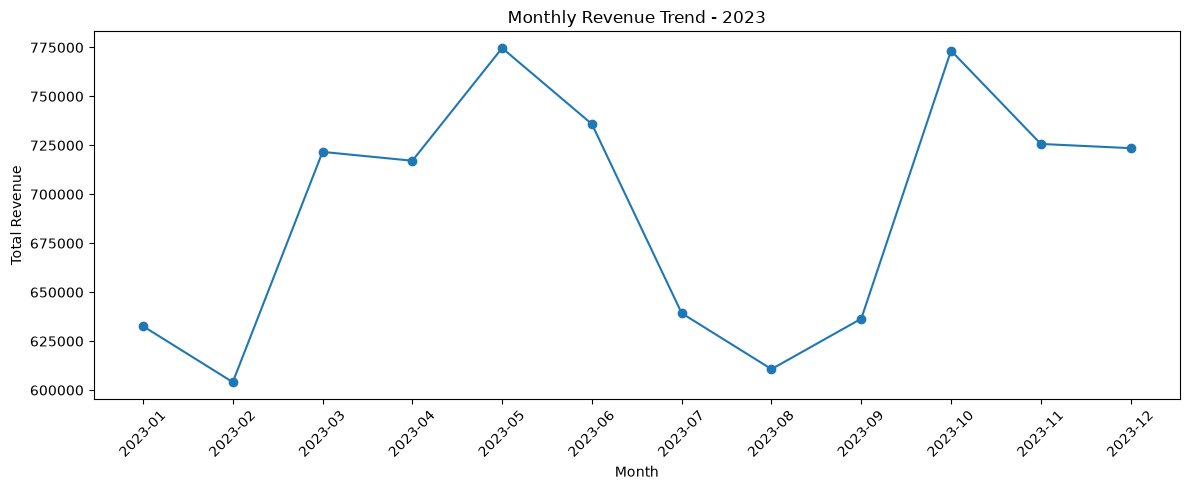

In [79]:
# Group data by month and analyse monthly revenue
df['pickup_month'] = df['tpep_pickup_datetime'].dt.to_period('M')

monthly_revenue = (
    df.groupby('pickup_month')['total_amount']
      .sum()
      .reset_index()
)
monthly_revenue['pickup_month'] = (
    monthly_revenue['pickup_month'].astype(str)
)

print(monthly_revenue)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue['pickup_month'],
    monthly_revenue['total_amount'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Revenue Trend - 2023')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Monthly_Revenue_Trend.png')
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Quarterly Revenue:
quarter
1    1958371.11
2    2227659.96
3    1886427.89
4    2222601.32
Name: total_amount, dtype: float64

Quarterly Revenue Proportion (%):
quarter
1    23.61
2    26.86
3    22.74
4    26.79
Name: total_amount, dtype: float64
            Revenue  Proportion (%)
quarter                            
1        1958371.11       23.608883
2        2227659.96       26.855259
3        1886427.89       22.741581
4        2222601.32       26.794276


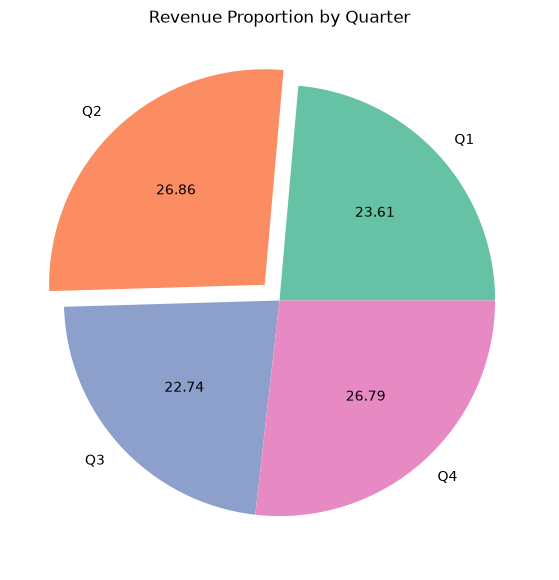

In [80]:
# Calculate proportion of each quarter
df['quarter'] = (
    df['tpep_pickup_datetime'].dt.quarter
)

# Calculate revenue by quarter

quarterly_revenue = (
    df.groupby('quarter')['total_amount']
      .sum()
)

print("Quarterly Revenue:")
print(quarterly_revenue)

# Calculate proportion of each quarter

quarterly_proportion = (
    quarterly_revenue /
    quarterly_revenue.sum()
) * 100

print("\nQuarterly Revenue Proportion (%):")

print(
    quarterly_proportion.round(2)
)

quarterly_summary = pd.DataFrame({
    'Revenue': quarterly_revenue,
    'Proportion (%)': quarterly_proportion
})

print(quarterly_summary)

plt.figure(figsize=(7, 7))

plt.pie(
    quarterly_revenue,
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    autopct='%1.2f',
    colors=['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3'], explode=(0,.1,0,0)
)

plt.title('Revenue Proportion by Quarter')
plt.savefig('Revenue_per_Quarter.png')
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Records used: 284679


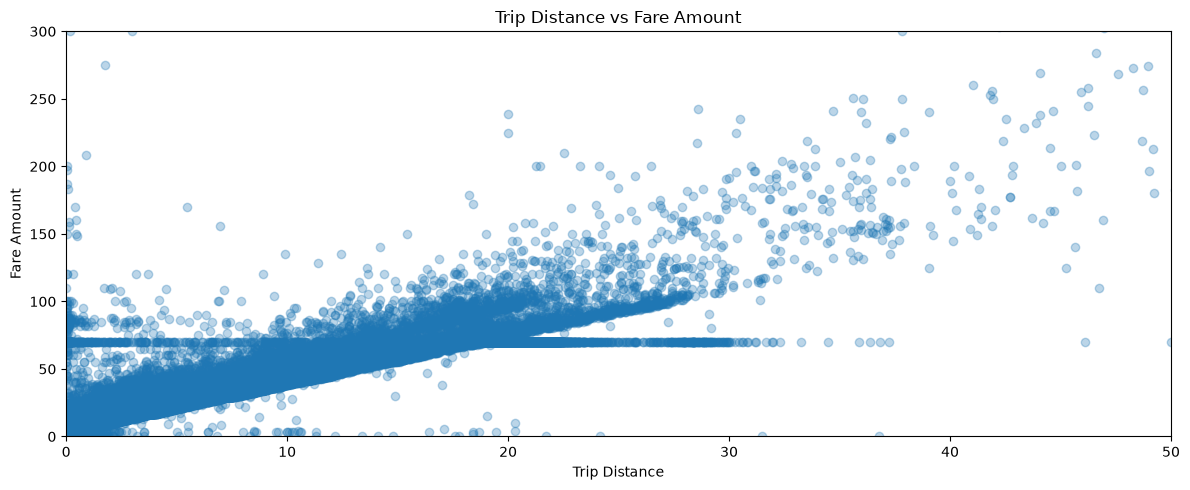

In [81]:
# Show how trip fare is affected by distance

df_distance = df[
    df['trip_distance'] > 0
].copy()

print("Records used:", len(df_distance))

plt.figure(figsize=(12, 5))

plt.scatter(
    df_distance['trip_distance'],
    df_distance['fare_amount'],
    alpha=0.3
)

plt.xlim(0, 50)
plt.ylim(0, 300)

plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')

plt.tight_layout()
plt.savefig('Relationship-trip distance and fare.png')
plt.show()



**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [82]:
corr_value = df_distance[
    'trip_distance'
].corr(
    df_distance['fare_amount']
)

print(
    f"Correlation between trip distance and fare amount: {corr_value:.4f}"
)


Correlation between trip distance and fare amount: 0.9445


In [83]:
# Show relationship between fare and trip duration
# Calculate trip duration in minutes

df['trip_duration'] = (
    df['tpep_dropoff_datetime'] -
    df['tpep_pickup_datetime']
).dt.total_seconds() / 60

print(df['trip_duration'].describe())

count    288058.000000
mean         17.207237
std          42.080532
min         -54.300000
25%           7.533333
50%          12.466667
75%          20.350000
max        6266.383333
Name: trip_duration, dtype: float64


In [84]:
df_duration = df[
    df['trip_duration'] > 0
].copy()

fare_duration_corr = df_duration[
    'fare_amount'
].corr(
    df_duration['trip_duration']
)

print(
    f"Correlation between fare amount and trip duration: "
    f"{fare_duration_corr:.4f}"
)

Correlation between fare amount and trip duration: 0.2595


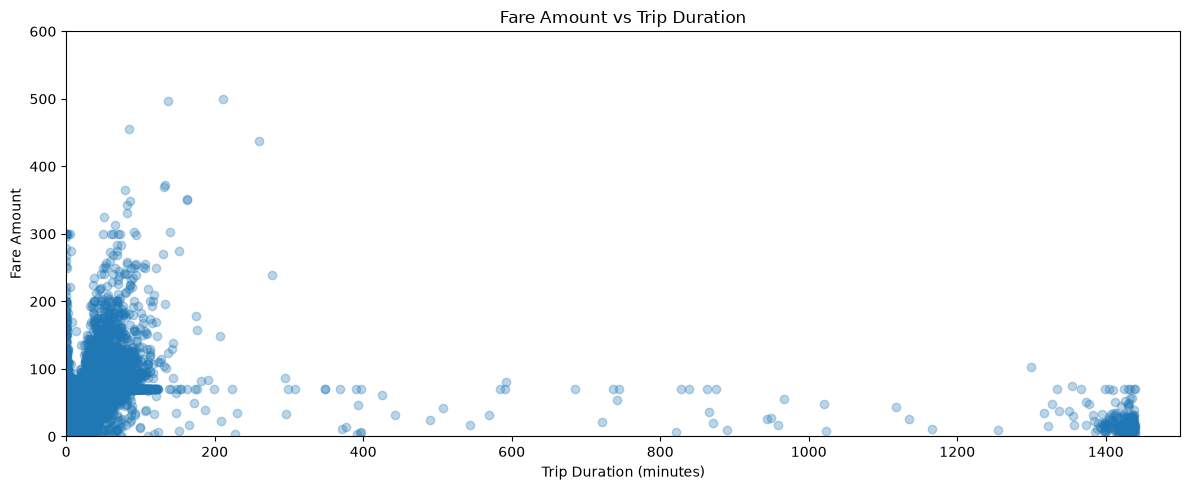

In [85]:
plt.figure(figsize=(12, 5))

plt.scatter(
    df_duration['trip_duration'],
    df_duration['fare_amount'],
    alpha=0.3
)

plt.xlim(0, 1500)
plt.ylim(0, 600)

plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Trip Duration')

plt.tight_layout()
plt.savefig('correlation_fare_and_trip_duration.png')
plt.show()


Correlation between fare amount and passenger count: 0.0497


<Figure size 1200x500 with 0 Axes>

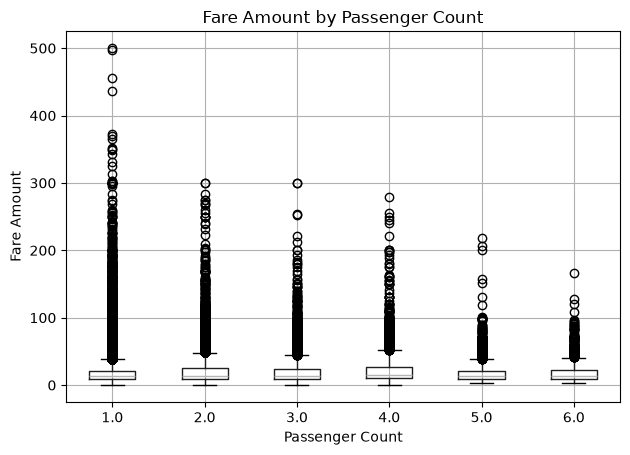

In [86]:
# Show relationship between fare and number of passengers
corr_value = df['fare_amount'].corr(
    df['passenger_count']
)

print(
    f"Correlation between fare amount and passenger count: "
    f"{corr_value:.4f}"
)

plt.figure(figsize=(12, 5))

df.boxplot(
    column='fare_amount',
    by='passenger_count'
)

plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.title('Fare Amount by Passenger Count')

plt.suptitle('')

plt.tight_layout()
plt.savefig('relationship_between_fare_and_number_of_passengers.png')
plt.show()


Correlation between tip amount and trip distance: 0.5890


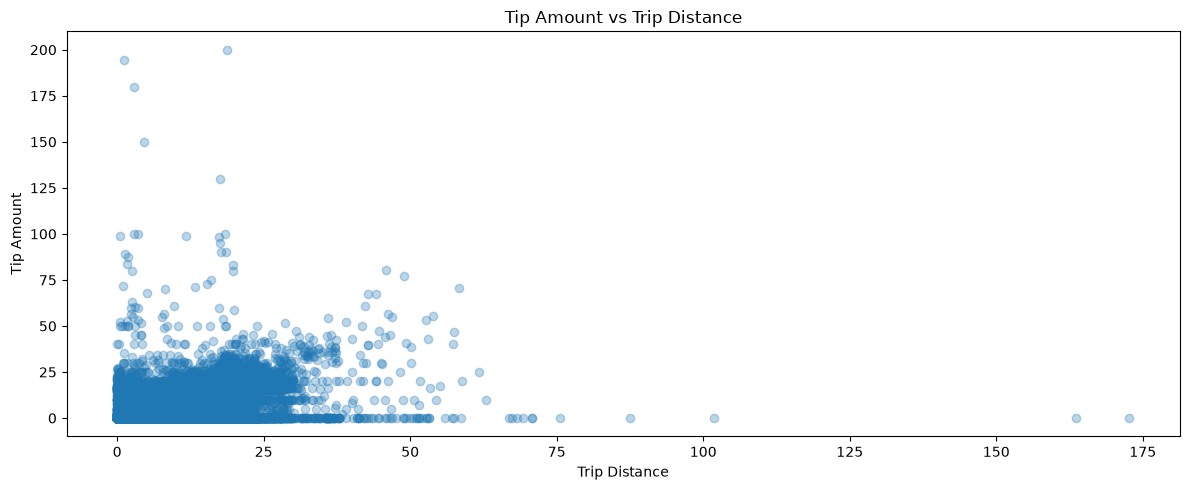

In [87]:
# Show relationship between tip and trip distance
df_tip_distance = df[
    df['trip_distance'] > 0
].copy()

tip_distance_corr = df_tip_distance[
    'tip_amount'
].corr(
    df_tip_distance['trip_distance']
)

print(
    f"Correlation between tip amount and trip distance: "
    f"{tip_distance_corr:.4f}"
)

plt.figure(figsize=(12, 5))

plt.scatter(
    df_tip_distance['trip_distance'],
    df_tip_distance['tip_amount'],
    alpha=0.3
)

plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip Amount vs Trip Distance')

plt.tight_layout()
plt.savefig('relationship_between_tip_and_trip_distance.png')
plt.show()


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

Payment Type Counts:
payment_type
1    234212
2     50312
3      1427
4      2107
Name: count, dtype: int64

Payment Type Percentage:
payment_type
1    81.31
2    17.47
3     0.50
4     0.73
Name: proportion, dtype: float64
  Payment Type   Count  Percentage
0  Credit card  234212       81.31
1         Cash   50312       17.47
2    No charge    1427        0.50
3      Dispute    2107        0.73


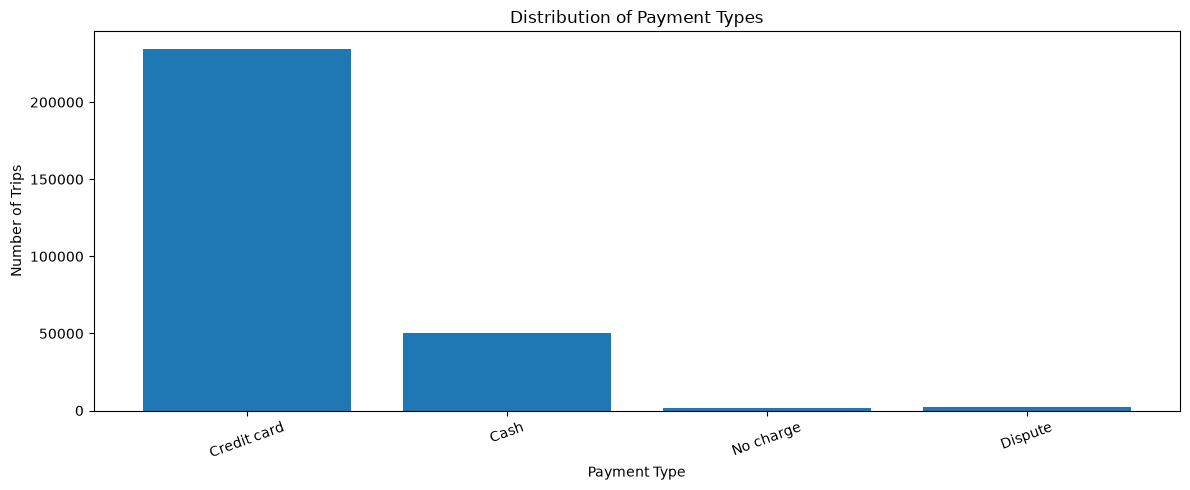

In [88]:
# Analyse the distribution of different payment types (payment_type).

payment_counts = df['payment_type'].value_counts().sort_index()

print("Payment Type Counts:")
print(payment_counts)

# Calculate percentage distribution

payment_percentage = (
    df['payment_type']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nPayment Type Percentage:")
print(payment_percentage.round(2))

# Create payment type summary

payment_labels = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

payment_summary = pd.DataFrame({
    'Payment Type': payment_counts.index.map(payment_labels),
    'Count': payment_counts.values,
    'Percentage': payment_percentage.values.round(2)
})

print(payment_summary)

plt.figure(figsize=(12, 5))

plt.bar(
    payment_summary['Payment Type'],
    payment_summary['Count']
)

plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('distribution_of_payment_types.png')
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute

##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [89]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [90]:
# import geopandas as gpd
shapefile_path = r'D:\Datasets and Dictionary-NYC\jupyter\Datasets and Dictionary NYC\taxi_zones\taxi_zones.shp'

# Read the shapefile using geopandas
zones = gpd.read_file(shapefile_path)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


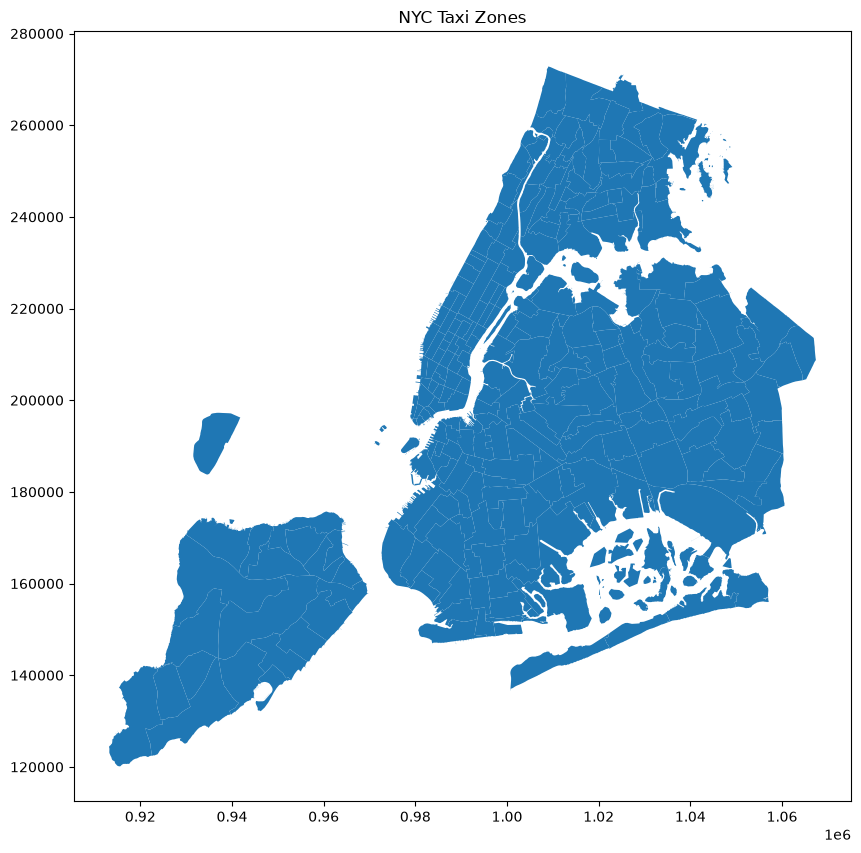

In [92]:
print(zones.info())
zones.plot(figsize=(12, 10)
)

plt.title('NYC Taxi Zones')
plt.savefig('nyc-taxi-zones.png')
plt.show()


Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [93]:
# Merge zones and trip records using locationID and PULocationID
df_geo = df.merge(
    zones[['LocationID', 'zone', 'borough', 'geometry']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

print(df_geo.shape)

df_geo.head()
print(
    "Trips without matching pickup zone:",
    df_geo['zone'].isnull().sum()
)

df_geo[
    df_geo['zone'].isnull()
][['PULocationID']].drop_duplicates()

(288070, 32)
Trips without matching pickup zone: 2968


,PULocationID
61,264
790,265
183162,57


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [95]:
# Group data by location and calculate the number of trips

trip_counts = (
    df.groupby('PULocationID')
      .size()
      .reset_index(name='trip_count')
)

trip_counts = trip_counts.sort_values(
    'trip_count',
    ascending=False
)

print(trip_counts.head(20))


     PULocationID  trip_count
109           132       15315
202           237       13788
137           161       13540
201           236       12299
138           162       10413
159           186       10132
115           138       10080
119           142        9632
195           230        9584
146           170        8514
139           163        8433
204           239        7981
199           234        7704
38             48        7667
57             68        7618
68             79        6860
118           141        6795
140           164        6689
213           249        6338
90            107        6120


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [96]:
# Merge trip counts back to the zones GeoDataFrame

zones_trips = zones.merge(
    trip_counts,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

# Locations with no trips should have 0
zones_trips['trip_count'] = (
    zones_trips['trip_count']
    .fillna(0)
)

print(
    zones_trips[
        ['LocationID', 'zone', 'borough', 'trip_count']
    ].head()
)

zones_trips['trip_count'] = (
    zones_trips['trip_count'].astype(int)
)

   LocationID                     zone        borough  trip_count
0           1           Newark Airport            EWR        35.0
1           2              Jamaica Bay         Queens         0.0
2           3  Allerton/Pelham Gardens          Bronx         0.0
3           4            Alphabet City      Manhattan       310.0
4           5            Arden Heights  Staten Island         0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

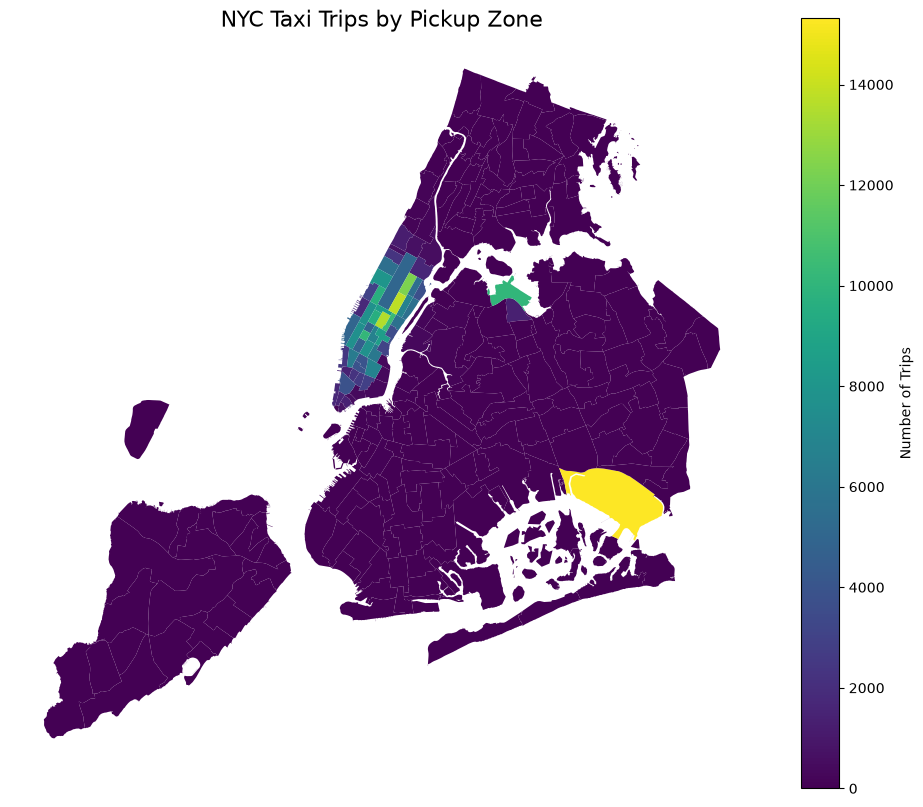

In [97]:
# Define figure and axis
fig, ax = plt.subplots(
    1,
    1,
    figsize=(12, 10)
)

# Plot the map and display it

zones_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'vertical'
    }
)

ax.set_title(
    'NYC Taxi Trips by Pickup Zone',
    fontsize=16
)

ax.set_axis_off()
plt.savefig('nyc-taxi-trips-pickup-zones.png')
plt.show()


In [98]:
# can you try displaying the zones DF sorted by the number of trips?

busiest_zones = zones_trips[
    [
        'LocationID',
        'zone',
        'borough',
        'trip_count'
    ]
].sort_values(
    'trip_count',
    ascending=False
)

print(busiest_zones.head(20))

     LocationID                          zone    borough  trip_count
131         132                   JFK Airport     Queens       15315
236         237         Upper East Side South  Manhattan       13788
160         161                Midtown Center  Manhattan       13540
235         236         Upper East Side North  Manhattan       12299
161         162                  Midtown East  Manhattan       10413
185         186  Penn Station/Madison Sq West  Manhattan       10132
137         138             LaGuardia Airport     Queens       10080
141         142           Lincoln Square East  Manhattan        9632
229         230     Times Sq/Theatre District  Manhattan        9584
169         170                   Murray Hill  Manhattan        8514
162         163                 Midtown North  Manhattan        8433
238         239         Upper West Side South  Manhattan        7981
233         234                      Union Sq  Manhattan        7704
47           48                  C

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


**Busiest Hour**

In [99]:

df['pickup_hour'] = df[
    'tpep_pickup_datetime'
].dt.hour

busiest_hour = (
    df['pickup_hour']
    .value_counts()
    .sort_values(ascending=False)
)

print(busiest_hour.head())

pickup_hour
18    20475
17    19551
19    18421
15    18093
16    18006
Name: count, dtype: int64


**Busiest day**

In [100]:
df['pickup_day'] = df[
    'tpep_pickup_datetime'
].dt.day_name()

busiest_day = (
    df['pickup_day']
    .value_counts()
    .sort_values(ascending=False)
)

print(busiest_day)

pickup_day
Thursday     45011
Wednesday    44207
Friday       42780
Saturday     41902
Tuesday      41872
Sunday       36595
Monday       35691
Name: count, dtype: int64


**Busiest Month**

In [101]:
df['pickup_month_num'] = df[
    'tpep_pickup_datetime'
].dt.month

busiest_month = (
    df['pickup_month_num']
    .value_counts()
    .sort_values(ascending=False)
)

print(busiest_month)

pickup_month_num
5     26631
10    25992
3     25750
6     25182
4     25120
11    25021
12    24974
1     23147
2     22208
7     21908
9     21147
8     20978
Name: count, dtype: int64


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

In [102]:
# ==========================================================
# Preparation for Detailed EDA
# ==========================================================

# Make sure datetime columns are datetime
df['tpep_pickup_datetime'] = pd.to_datetime(
    df['tpep_pickup_datetime']
)

df['tpep_dropoff_datetime'] = pd.to_datetime(
    df['tpep_dropoff_datetime']
)

# Pickup hour
df['pickup_hour'] = (
    df['tpep_pickup_datetime'].dt.hour
)

# Day of week
df['day_of_week'] = (
    df['tpep_pickup_datetime'].dt.day_name()
)

# Day number - Monday=0, Sunday=6
df['day_num'] = (
    df['tpep_pickup_datetime'].dt.dayofweek
)

# Trip duration in minutes
df['trip_duration_minutes'] = (
    df['tpep_dropoff_datetime']
    - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Trip duration in hours
df['trip_duration_hours'] = (
    df['trip_duration_minutes'] / 60
)

print(df[
    [
        'tpep_pickup_datetime',
        'pickup_hour',
        'day_of_week',
        'trip_duration_minutes'
    ]
].head())

  tpep_pickup_datetime  pickup_hour day_of_week  trip_duration_minutes
0  2023-04-21 01:37:42            1      Friday              12.050000
1  2023-01-10 14:11:52           14     Tuesday               9.216667
2  2023-02-04 15:03:50           15    Saturday              43.966667
3  2023-03-24 12:33:07           12      Friday              26.133333
4  2023-09-05 17:03:28           17     Tuesday               9.266667


**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [103]:
# Find routes which have the slowest speeds at different times of the day
route_data = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration_hours'] > 0) &
    (df['PULocationID'] != df['DOLocationID'])
].copy()

route_hour = (
    route_data
    .groupby(
        [
            'PULocationID',
            'DOLocationID',
            'pickup_hour'
        ]
    )
    .agg(
        avg_distance=('trip_distance', 'mean'),
        avg_duration_hours=('trip_duration_hours', 'mean'),
        trip_count=('trip_distance', 'size')
    )
    .reset_index()
)

route_hour['avg_speed_mph'] = (
    route_hour['avg_distance'] /
    route_hour['avg_duration_hours']
)

slow_routes = route_hour[
    route_hour['trip_count'] >= 10
].sort_values(
    'avg_speed_mph'
)

print(
    slow_routes[
        [
            'PULocationID',
            'DOLocationID',
            'pickup_hour',
            'avg_distance',
            'avg_duration_hours',
            'trip_count',
            'avg_speed_mph'
        ]
    ].head(20)
)

       PULocationID  DOLocationID  pickup_hour  avg_distance  \
41684           186           164           12      0.659231   
4275             48           161           16      0.972000   
17541           114           249           21      0.827500   
44863           229           162           12      0.693529   
46144           230           161            8      0.726667   
51557           236           263            9      0.822778   
38679           164           246           20      1.339091   
40112           170           164           19      0.702273   
33824           161            90           16      1.703000   
51841           237            75            9      1.550000   
55615           246           161           18      1.783636   
32283           151           238           14      0.684828   
49924           234           162           20      1.767273   
58572           262           141           15      1.103333   
34992           162            43       

How does identifying high-traffic, high-demand routes help us?

High-demand routes with low average speeds can indicate:

congestion
inefficient routes
longer travel times
higher driver time costs
potential demand/supply imbalance

This information can help a taxi company allocate vehicles during busy periods, identify congestion-heavy routes, and evaluate pricing or operational strategies.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

pickup_hour
0      8333
1      5430
2      3600
3      2262
4      1472
5      1509
6      3814
7      7558
8     10688
9     12074
10    13420
11    14508
12    15819
13    16212
14    17603
15    18093
16    18006
17    19551
18    20475
19    18421
20    16176
21    16292
22    15001
23    11741
Name: count, dtype: int64
Busiest hour: 18:00
Sampled trips during busiest hour: 20,475


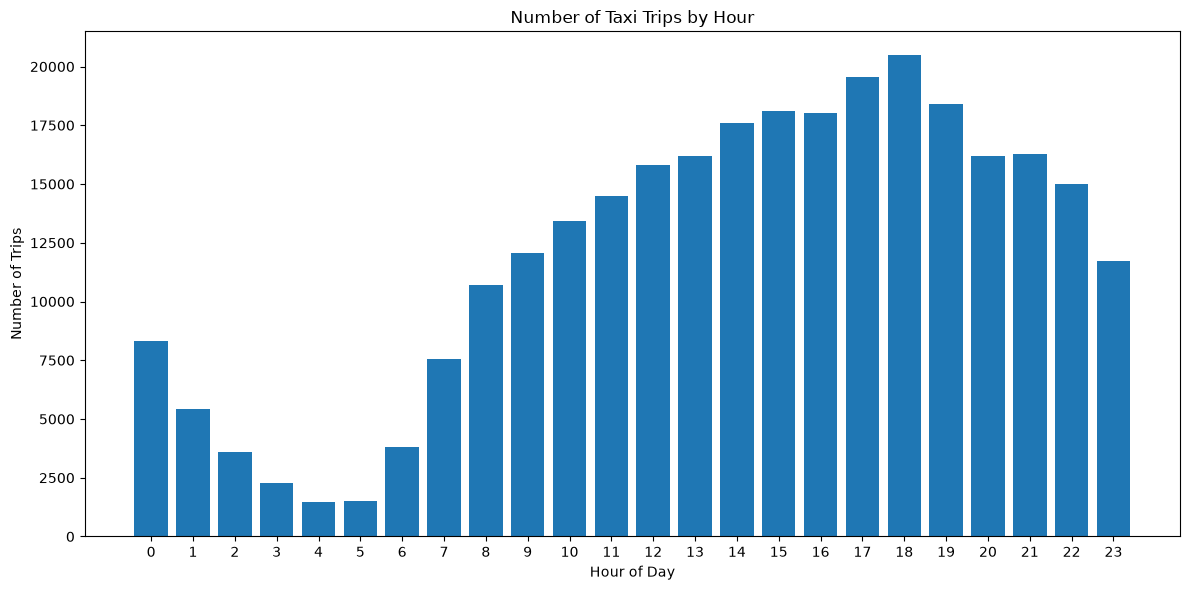

In [104]:
# Visualise the number of trips per hour and find the busiest hour
#trips per hour
hourly_trips = (
    df['pickup_hour']
    .value_counts()
    .sort_index()
)

print(hourly_trips)

# Busiest hour
busiest_hour = hourly_trips.idxmax()
busiest_hour_trips = hourly_trips.max()

print(
    f"Busiest hour: {busiest_hour}:00"
)

print(
    f"Sampled trips during busiest hour: "
    f"{busiest_hour_trips:,}"
)

plt.figure(figsize=(12, 6))

plt.bar(
    hourly_trips.index,
    hourly_trips.values
)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Number of Taxi Trips by Hour')

plt.xticks(range(24))
plt.tight_layout()
plt.savefig('number-of-taxi-trips-by-hour.png')
plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [105]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
# Sampling fraction
sample_fraction = 0.05

# Five busiest sampled hours
top_5_hours = (
    hourly_trips
    .sort_values(ascending=False)
    .head(5)
)

# Scale to estimated actual trips
top_5_actual = (
    top_5_hours / sample_fraction
)

print("Top 5 busiest hours - sampled:")
print(top_5_hours)

print("\nEstimated actual trips:")
print(top_5_actual.round().astype(int))



Top 5 busiest hours - sampled:
pickup_hour
18    20475
17    19551
19    18421
15    18093
16    18006
Name: count, dtype: int64

Estimated actual trips:
pickup_hour
18    409500
17    391020
19    368420
15    361860
16    360120
Name: count, dtype: int64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

  day_type  pickup_hour  trip_count
0  Weekday            0        4179
1  Weekday            1        2042
2  Weekday            2        1107
3  Weekday            3         667
4  Weekday            4         598


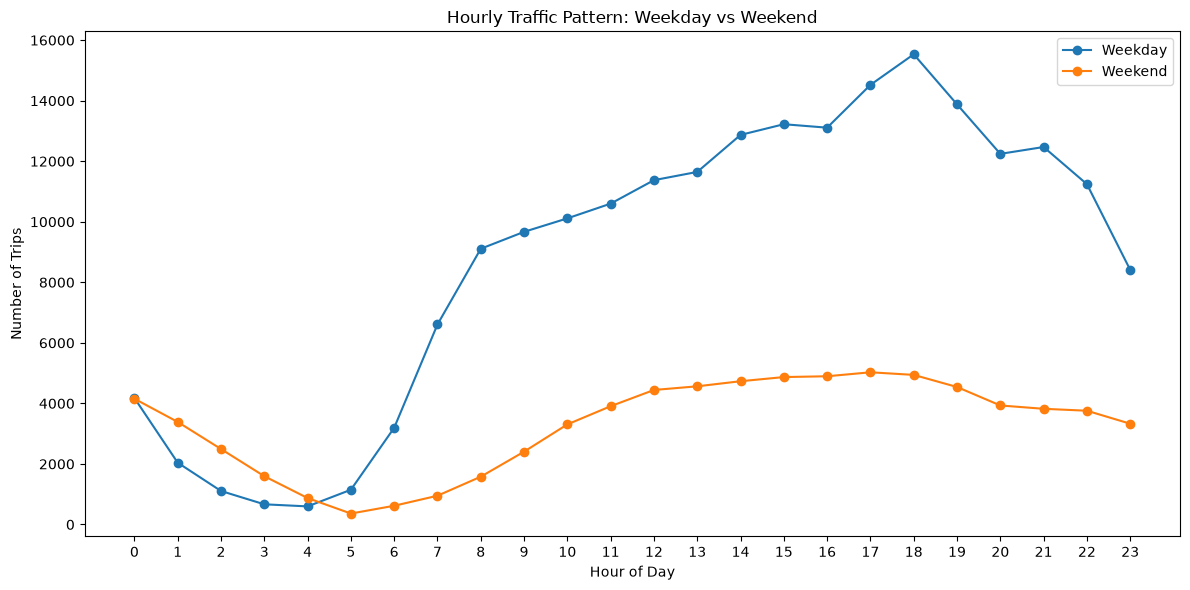

   day_type  pickup_hour  trip_count
18  Weekday           18       15533
17  Weekday           17       14523
19  Weekday           19       13879
15  Weekday           15       13223
16  Weekday           16       13109
14  Weekday           14       12870
21  Weekday           21       12470
20  Weekday           20       12244
13  Weekday           13       11647
12  Weekday           12       11375


In [106]:
# Compare traffic trends for the week days and weekends

df['day_type'] = df['day_num'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

weekday_weekend = (
    df.groupby(
        ['day_type', 'pickup_hour']
    )
    .size()
    .reset_index(name='trip_count')
)

print(weekday_weekend.head())

plt.figure(figsize=(12, 6))

for day_type in ['Weekday', 'Weekend']:

    temp = weekday_weekend[
        weekday_weekend['day_type'] == day_type
    ]

    plt.plot(
        temp['pickup_hour'],
        temp['trip_count'],
        marker='o',
        label=day_type
    )

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Traffic Pattern: Weekday vs Weekend')

plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.savefig('hourly-traffic-pattern-weekday-vs-weekendr.png')

plt.show()

#Peak Hours
print(
    weekday_weekend.sort_values(
        'trip_count',
        ascending=False
    ).head(10)
)

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

peak operating periods
quiet periods
weekday commuting patterns
weekend travel patterns
when additional taxis may be required

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

Top 10 Pickup Zones:
PULocationID
132    15315
237    13788
161    13540
236    12299
162    10413
186    10132
138    10080
142     9632
230     9584
170     8514
Name: count, dtype: int64

Top 10 Drop-off Zones:
DOLocationID
236    12846
237    12154
161    11192
230     9047
170     8492
162     8319
142     8151
239     7866
141     7733
163     7234
Name: count, dtype: int64


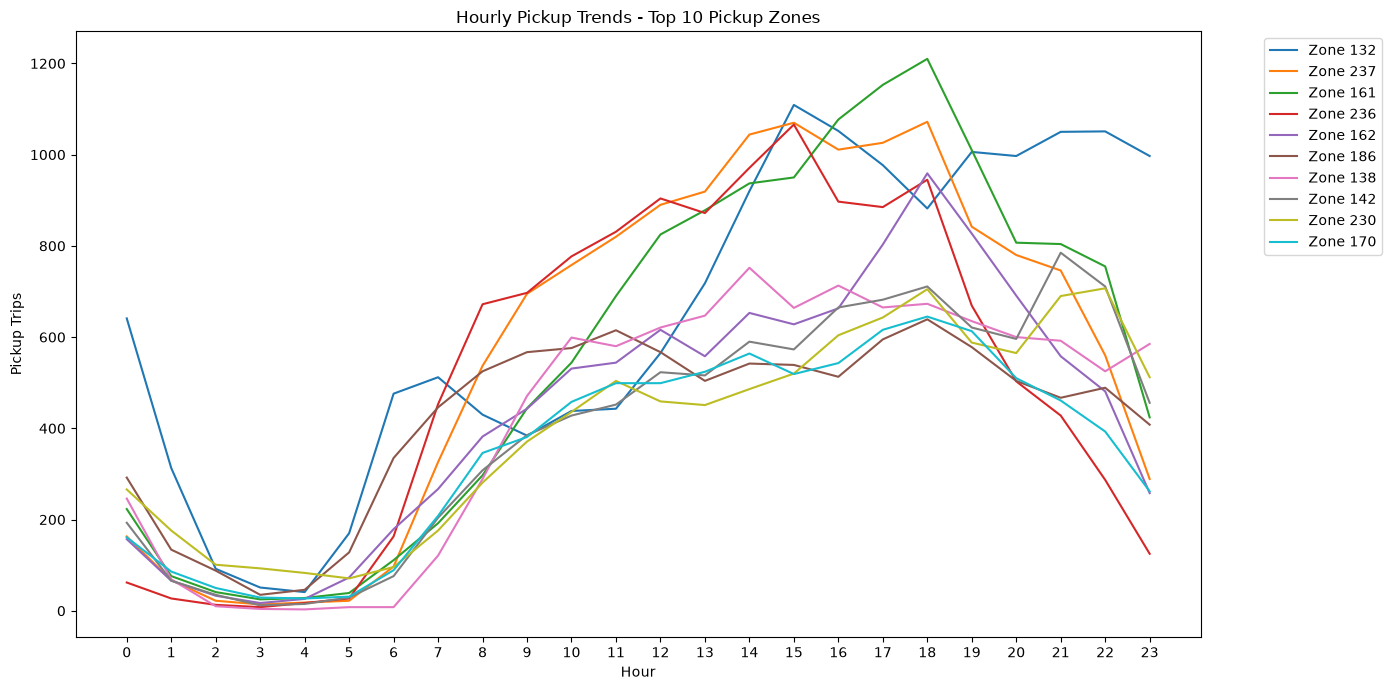

In [107]:
# Find top 10 pickup and dropoff zones
top_pickup_zones = (
    df['PULocationID']
    .value_counts()
    .head(10)
)

print("Top 10 Pickup Zones:")
print(top_pickup_zones)

top_dropoff_zones = (
    df['DOLocationID']
    .value_counts()
    .head(10)
)

print("\nTop 10 Drop-off Zones:")
print(top_dropoff_zones)

pickup_zone_hourly = (
    df[
        df['PULocationID'].isin(
            top_pickup_zones.index
        )
    ]
    .groupby(
        ['PULocationID', 'pickup_hour']
    )
    .size()
    .reset_index(name='trip_count')
)

plt.figure(figsize=(14, 7))

for zone in top_pickup_zones.index:

    temp = pickup_zone_hourly[
        pickup_zone_hourly['PULocationID'] == zone
    ]

    plt.plot(
        temp['pickup_hour'],
        temp['trip_count'],
        label=f'Zone {zone}'
    )

plt.xlabel('Hour')
plt.ylabel('Pickup Trips')
plt.title('Hourly Pickup Trends - Top 10 Pickup Zones')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(range(24))

plt.tight_layout()
plt.savefig('hourly-pickup-trends-top-10-pickup-zones.png')
plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [108]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = (
    df['PULocationID']
    .value_counts()
    .rename('pickup_count')
)

dropoff_counts = (
    df['DOLocationID']
    .value_counts()
    .rename('dropoff_count')
)
zone_flow = pd.concat(
    [
        pickup_counts,
        dropoff_counts
    ],
    axis=1
).fillna(0)

zone_flow['pickup_dropoff_ratio'] = (
    zone_flow['pickup_count'] /
    zone_flow['dropoff_count'].replace(0, pd.NA)
)

top_10_ratio = (
    zone_flow
    .dropna(subset=['pickup_dropoff_ratio'])
    .sort_values(
        'pickup_dropoff_ratio',
        ascending=False
    )
    .head(10)
)

print("Top 10 Pickup/Drop-off Ratios:")
print(top_10_ratio)

bottom_10_ratio = (
    zone_flow
    .dropna(subset=['pickup_dropoff_ratio'])
    .sort_values(
        'pickup_dropoff_ratio'
    )
    .head(10)
)

print("\nBottom 10 Pickup/Drop-off Ratios:")
print(bottom_10_ratio)

Top 10 Pickup/Drop-off Ratios:
     pickup_count  dropoff_count  pickup_dropoff_ratio
70         1322.0            147              8.993197
132       15315.0           3363              4.553970
138       10080.0           3458              2.914980
44            2.0              1              2.000000
186       10132.0           6298              1.608765
43         4972.0           3515              1.414509
114        3882.0           2771              1.400938
249        6338.0           4955              1.279112
162       10413.0           8319              1.251713
100        4732.0           3909              1.210540

Bottom 10 Pickup/Drop-off Ratios:
     pickup_count  dropoff_count  pickup_dropoff_ratio
108           0.0             22                   0.0
32            0.0             22                   0.0
20            0.0             21                   0.0
126           0.0             20                   0.0
94            0.0             19                   0.0

**Interpretation:**

High ratio → more pickups than drop-offs → potentially an inbound demand zone

Low ratio → more drop-offs than pickups → potentially an outbound zone

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [109]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_df = df[
    (df['pickup_hour'] >= 23) |
    (df['pickup_hour'] < 5)
].copy()

print("Night trips:", len(night_df))

night_pickups = (
    night_df['PULocationID']
    .value_counts()
    .head(10)
)

print("Top 10 Night Pickup Zones:")
print(night_pickups)

night_dropoffs = (
    night_df['DOLocationID']
    .value_counts()
    .head(10)
)

print("\nTop 10 Night Drop-off Zones:")
print(night_dropoffs)


Night trips: 32838
Top 10 Night Pickup Zones:
PULocationID
79     2396
132    2135
249    1923
48     1531
148    1503
114    1429
230    1231
186    1003
68      946
138     917
Name: count, dtype: int64

Top 10 Night Drop-off Zones:
DOLocationID
79     1291
48     1060
170     967
107     964
68      862
141     856
249     831
263     754
148     726
230     693
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [110]:
# Filter for night hours (11 PM to 5 AM)

# Nighttime trips
night_df = df[
    (df['pickup_hour'] >= 23) |
    (df['pickup_hour'] < 5)
].copy()

# Daytime trips
day_df = df[
    ~(
        (df['pickup_hour'] >= 23) |
        (df['pickup_hour'] < 5)
    )
].copy()

#Revenue Calculation
night_revenue = night_df['total_amount'].sum()

day_revenue = day_df['total_amount'].sum()

total_revenue = night_revenue + day_revenue

#calculateing Share
night_share = (
    night_revenue / total_revenue
) * 100

day_share = (
    day_revenue / total_revenue
) * 100

print(
    f"Nighttime revenue: ${night_revenue:,.2f}"
)

print(
    f"Daytime revenue: ${day_revenue:,.2f}"
)

print(
    f"Nighttime revenue share: {night_share:.2f}%"
)

print(
    f"Daytime revenue share: {day_share:.2f}%"
)

Nighttime revenue: $950,178.09
Daytime revenue: $7,344,882.19
Nighttime revenue share: 11.45%
Daytime revenue share: 88.55%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

   passenger_count  fare_per_mile_per_passenger
0              1.0                    10.813856
1              2.0                     6.981240
2              3.0                     4.434127
3              4.0                     3.788561
4              5.0                     1.768596
5              6.0                     1.321913


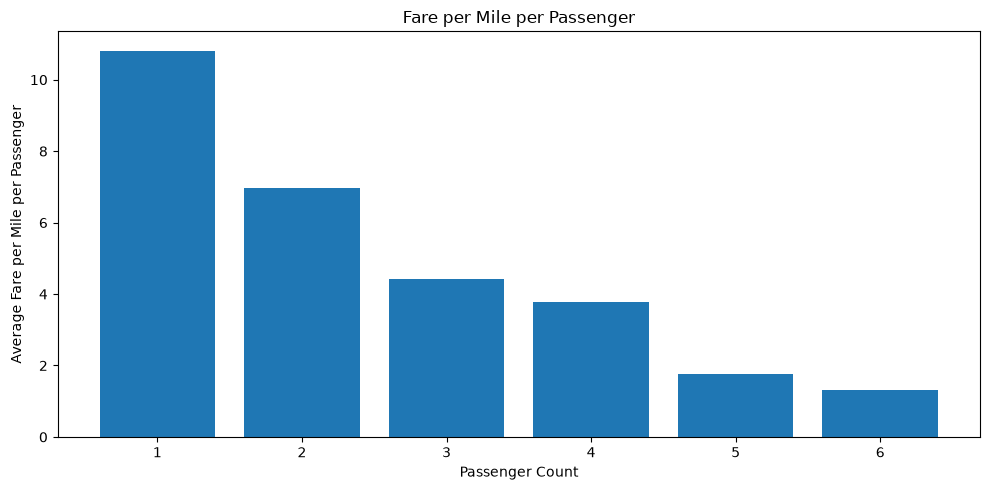

In [111]:
# Analyse the fare per mile per passenger for different passenger counts

pricing_df = df[
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0)
].copy()

pricing_df['fare_per_mile_per_passenger'] = (
    pricing_df['fare_amount'] /
    pricing_df['trip_distance'] /
    pricing_df['passenger_count']
)

fare_by_passengers = (
    pricing_df
    .groupby('passenger_count')
    ['fare_per_mile_per_passenger']
    .mean()
    .reset_index()
)

print(fare_by_passengers)

plt.figure(figsize=(10, 5))

plt.bar(
    fare_by_passengers['passenger_count'],
    fare_by_passengers[
        'fare_per_mile_per_passenger'
    ]
)

plt.xlabel('Passenger Count')
plt.ylabel('Average Fare per Mile per Passenger')
plt.title('Fare per Mile per Passenger')

plt.tight_layout()
plt.savefig('fare-per-mile-per-passenger.png')
plt.show()


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

Average fare per mile by hour:
pickup_hour
0     12.710768
1     10.229399
2     10.785463
3      7.302114
4     20.195772
5     20.307766
6     10.654699
7      9.671092
8     11.467170
9     10.888613
10    10.328519
11    11.796454
12    12.244708
13    12.560707
14    12.418170
15    12.801064
16    14.026416
17    11.375180
18    11.733289
19    11.193241
20     9.305185
21     9.525324
22     9.294862
23    10.567654
Name: fare_per_mile, dtype: float64

Average fare per mile by day:
day_of_week
Monday       11.478483
Tuesday      10.556806
Wednesday    11.190110
Thursday     11.619892
Friday       11.004018
Saturday     10.704298
Sunday       13.760395
Name: fare_per_mile, dtype: float64


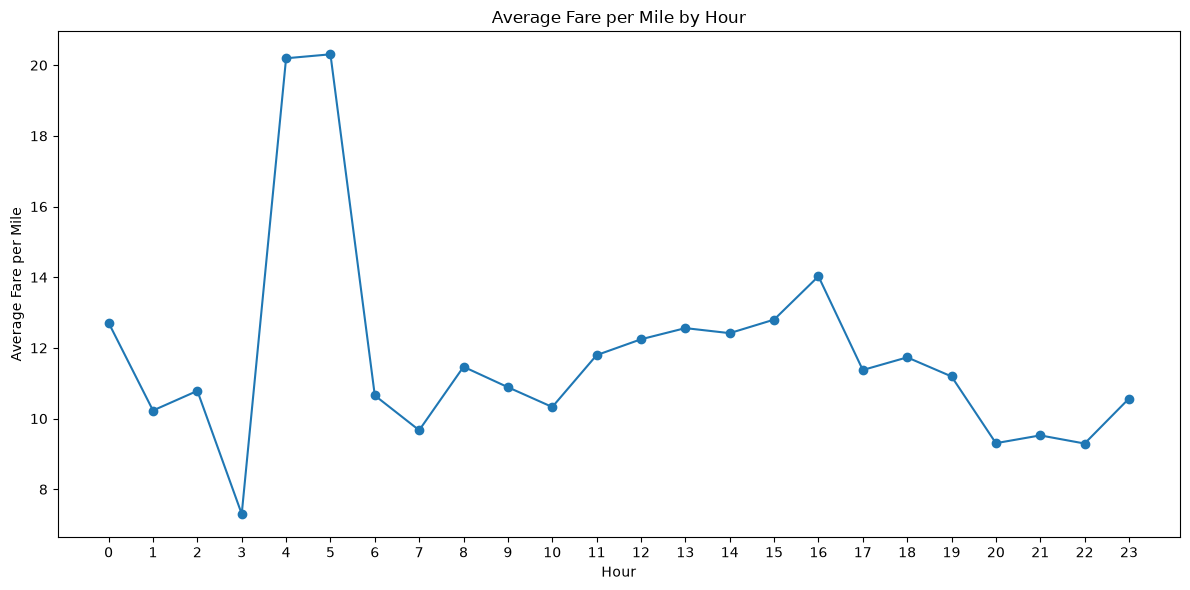

In [112]:
# Compare the average fare per mile for different days and for different times of the day

fare_mile_df = df[
    df['trip_distance'] > 0
].copy()

fare_mile_df['fare_per_mile'] = (
    fare_mile_df['fare_amount'] /
    fare_mile_df['trip_distance']
)

# by Hour
fare_per_mile_hour = (
    fare_mile_df
    .groupby('pickup_hour')['fare_per_mile']
    .mean()
)

print("Average fare per mile by hour:")
print(fare_per_mile_hour)

# By day of week
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

fare_per_mile_day = (
    fare_mile_df
    .groupby('day_of_week')['fare_per_mile']
    .mean()
    .reindex(day_order)
)

print("\nAverage fare per mile by day:")
print(fare_per_mile_day)

plt.figure(figsize=(12, 6))

plt.plot(
    fare_per_mile_hour.index,
    fare_per_mile_hour.values,
    marker='o'
)

plt.xlabel('Hour')
plt.ylabel('Average Fare per Mile')
plt.title('Average Fare per Mile by Hour')

plt.xticks(range(24))
plt.tight_layout()
plt.savefig('average-fare-per-mile-by-hour.png')
plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

   VendorID  pickup_hour  fare_per_mile
0         1            0       7.136199
1         1            1       6.630251
2         1            2       7.182141
3         1            3       6.692504
4         1            4       7.012626


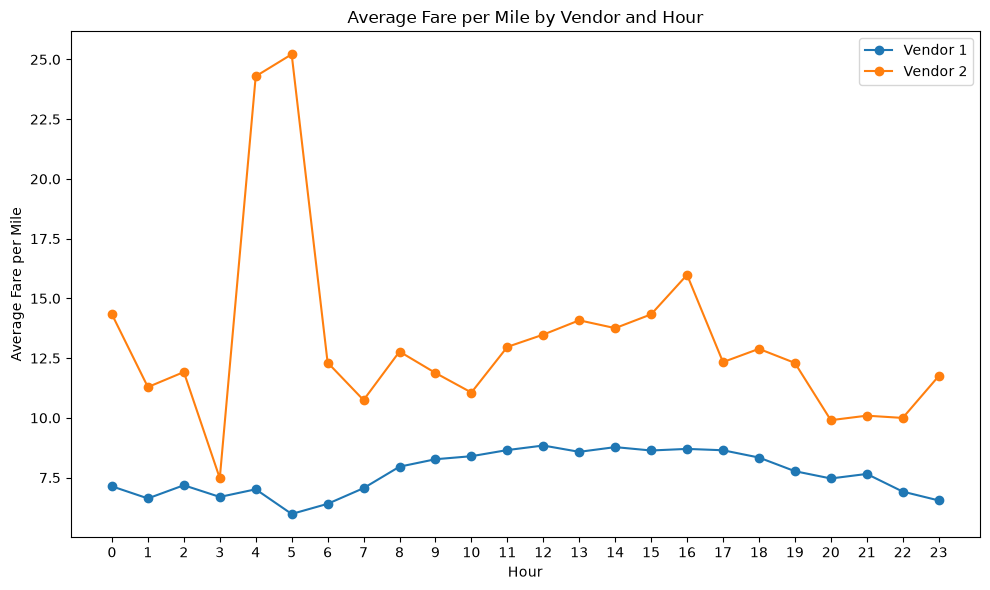

In [113]:
# Compare fare per mile for different vendors
vendor_hour_fare = (
    fare_mile_df
    .groupby(
        ['VendorID', 'pickup_hour']
    )['fare_per_mile']
    .mean()
    .reset_index()
)

print(vendor_hour_fare.head())

plt.figure(figsize=(10, 6))

for vendor in sorted(
    vendor_hour_fare['VendorID'].unique()
):

    temp = vendor_hour_fare[
        vendor_hour_fare['VendorID'] == vendor
    ]

    plt.plot(
        temp['pickup_hour'],
        temp['fare_per_mile'],
        marker='o',
        label=f'Vendor {vendor}'
    )

plt.xlabel('Hour')
plt.ylabel('Average Fare per Mile')
plt.title('Average Fare per Mile by Vendor and Hour')

plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.savefig('average-fare-per-mile-by-vendor-and-hour.png')
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


   VendorID      distance_tier  fare_per_mile
0         1      Up to 2 miles       9.736057
1         1       2 to 5 miles       6.364415
2         1  More than 5 miles       4.455500
3         2      Up to 2 miles      18.275245
4         2       2 to 5 miles       6.550340
5         2  More than 5 miles       4.503487
VendorID                  1          2
distance_tier                         
Up to 2 miles      9.736057  18.275245
2 to 5 miles       6.364415   6.550340
More than 5 miles  4.455500   4.503487


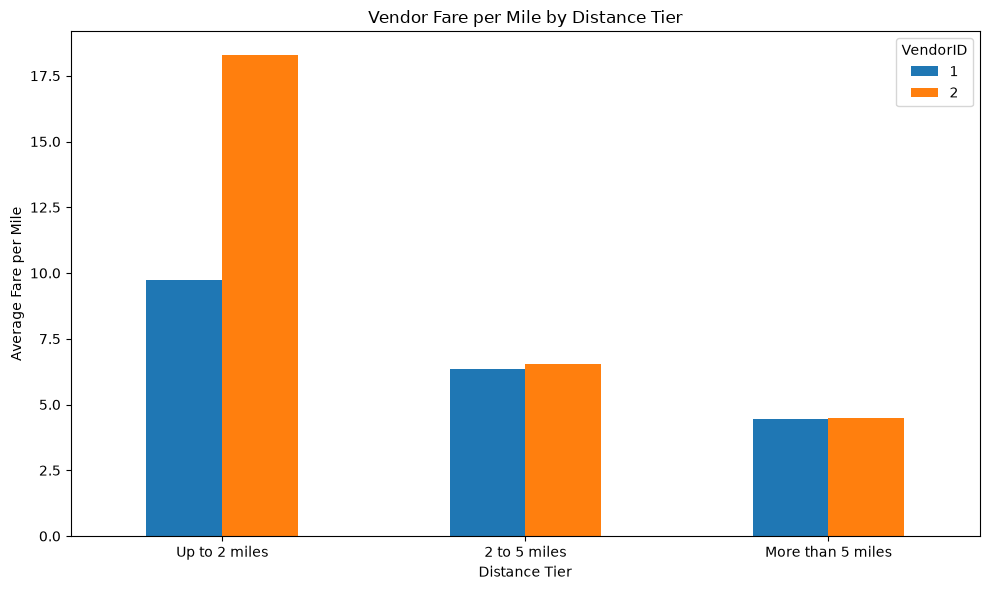

In [114]:
# Defining distance tiers
# ≤ 2 miles
# > 2 and ≤ 5 miles
# > 5 miles

fare_mile_df['distance_tier'] = pd.cut(
    fare_mile_df['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=[
        'Up to 2 miles',
        '2 to 5 miles',
        'More than 5 miles'
    ],
    include_lowest=True
)

vendor_tier_fare = (
    fare_mile_df
    .groupby(
        ['VendorID', 'distance_tier'],
        observed=True
    )['fare_per_mile']
    .mean()
    .reset_index()
)

print(vendor_tier_fare)

# Comparison Table

vendor_tier_pivot = vendor_tier_fare.pivot(
    index='distance_tier',
    columns='VendorID',
    values='fare_per_mile'
)

print(vendor_tier_pivot)

vendor_tier_pivot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per Mile')
plt.title('Vendor Fare per Mile by Distance Tier')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('vendor-fare-per-mile-by-distance-tier.png')
plt.show()



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

distance_category
0-2 miles     22.434917
2-5 miles     18.932817
5-10 miles    17.404071
10+ miles     16.099995
Name: tip_percentage, dtype: float64
passenger_count
1.0    20.831963
2.0    19.650791
3.0    19.162326
4.0    17.542113
5.0    20.632875
6.0    20.485962
Name: tip_percentage, dtype: float64
pickup_hour
0     20.213941
1     20.529871
2     21.061613
3     20.449959
4     18.567658
5     18.022347
6     19.248537
7     19.982923
8     20.406591
9     20.027393
10    19.443233
11    19.187238
12    19.249309
13    19.079689
14    19.175405
15    19.164129
16    20.997947
17    21.720837
18    22.228570
19    22.100327
20    21.519983
21    21.639034
22    21.310597
23    20.874742
Name: tip_percentage, dtype: float64


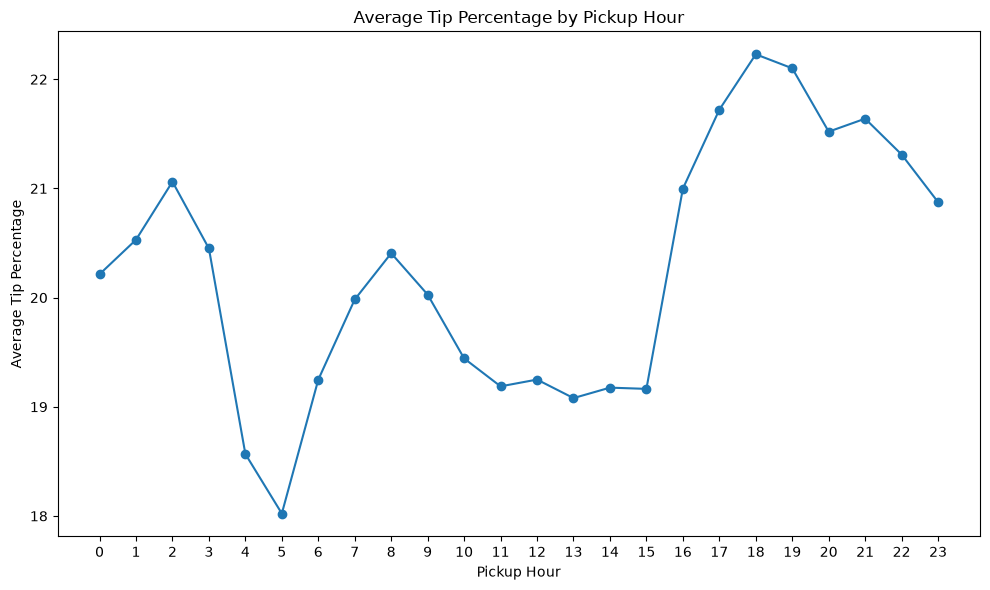

In [115]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Tip % = tip_amount / fare_amount × 100
tip_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

tip_df['tip_percentage'] = (
    tip_df['tip_amount'] /
    tip_df['fare_amount']
) * 100

# Tip Percent by distance

tip_df['distance_category'] = pd.cut(
    tip_df['trip_distance'],
    bins=[0, 2, 5, 10, float('inf')],
    labels=[
        '0-2 miles',
        '2-5 miles',
        '5-10 miles',
        '10+ miles'
    ],
    include_lowest=True
)

tip_by_distance = (
    tip_df
    .groupby(
        'distance_category',
        observed=True
    )['tip_percentage']
    .mean()
)

print(tip_by_distance)

# Tip % by passenger count

tip_by_passengers = (
    tip_df
    .groupby('passenger_count')
    ['tip_percentage']
    .mean()
)

print(tip_by_passengers)

#Tip % by pickup hour

tip_by_hour = (
    tip_df
    .groupby('pickup_hour')
    ['tip_percentage']
    .mean()
)

print(tip_by_hour)


plt.figure(figsize=(10, 6))

plt.plot(
    tip_by_hour.index,
    tip_by_hour.values,
    marker='o'
)

plt.xlabel('Pickup Hour')
plt.ylabel('Average Tip Percentage')
plt.title('Average Tip Percentage by Pickup Hour')

plt.xticks(range(24))
plt.tight_layout()
plt.savefig('average-tip-percentage-by-pickup-hour.png')
plt.show()


Factors lead to low tip percentages?

In [116]:
print(
    tip_by_distance.sort_values()
)

print(
    tip_by_passengers.sort_values()
)

print(
    tip_by_hour.sort_values()
)

distance_category
10+ miles     16.099995
5-10 miles    17.404071
2-5 miles     18.932817
0-2 miles     22.434917
Name: tip_percentage, dtype: float64
passenger_count
4.0    17.542113
3.0    19.162326
2.0    19.650791
6.0    20.485962
5.0    20.632875
1.0    20.831963
Name: tip_percentage, dtype: float64
pickup_hour
5     18.022347
4     18.567658
13    19.079689
15    19.164129
14    19.175405
11    19.187238
6     19.248537
12    19.249309
10    19.443233
7     19.982923
9     20.027393
0     20.213941
8     20.406591
3     20.449959
1     20.529871
23    20.874742
16    20.997947
2     21.061613
22    21.310597
20    21.519983
21    21.639034
17    21.720837
19    22.100327
18    22.228570
Name: tip_percentage, dtype: float64


In [118]:
#Note: This lets to identify which distance ranges, passenger counts, or pickup hours have the lowest observed average tip percentages.

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [119]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# tip percentage < 10%
# tip percentage > 25%

low_tip = tip_df[
    tip_df['tip_percentage'] < 10
].copy()

high_tip = tip_df[
    tip_df['tip_percentage'] > 25
].copy()

print("Low tip trips:", len(low_tip))
print("High tip trips:", len(high_tip))

comparison = pd.DataFrame({
    'Low Tip (<10%)': [
        low_tip['trip_distance'].mean(),
        low_tip['passenger_count'].mean(),
        low_tip['pickup_hour'].mean(),
        low_tip['fare_amount'].mean()
    ],
    'High Tip (>25%)': [
        high_tip['trip_distance'].mean(),
        high_tip['passenger_count'].mean(),
        high_tip['pickup_hour'].mean(),
        high_tip['fare_amount'].mean()
    ]
}, index=[
    'Average Trip Distance',
    'Average Passenger Count',
    'Average Pickup Hour',
    'Average Fare'
])

print(comparison)

Low tip trips: 73248
High tip trips: 128769
                         Low Tip (<10%)  High Tip (>25%)
Average Trip Distance          3.831308         2.292545
Average Passenger Count        1.441213         1.362300
Average Pickup Hour           13.976491        14.602156
Average Fare                  21.316133        14.375638


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

pickup_hour
0     1.420617
1     1.439963
2     1.442222
3     1.459328
4     1.398098
5     1.294235
6     1.248558
7     1.278910
8     1.295284
9     1.312407
10    1.354173
11    1.375172
12    1.385233
13    1.386072
14    1.398171
15    1.421323
16    1.399867
17    1.393995
18    1.376508
19    1.401498
20    1.405045
21    1.438436
22    1.432438
23    1.426965
Name: passenger_count, dtype: float64
day_of_week
Monday       1.363929
Tuesday      1.328310
Wednesday    1.337639
Thursday     1.345205
Friday       1.409444
Saturday     1.483891
Sunday       1.462659
Name: passenger_count, dtype: float64


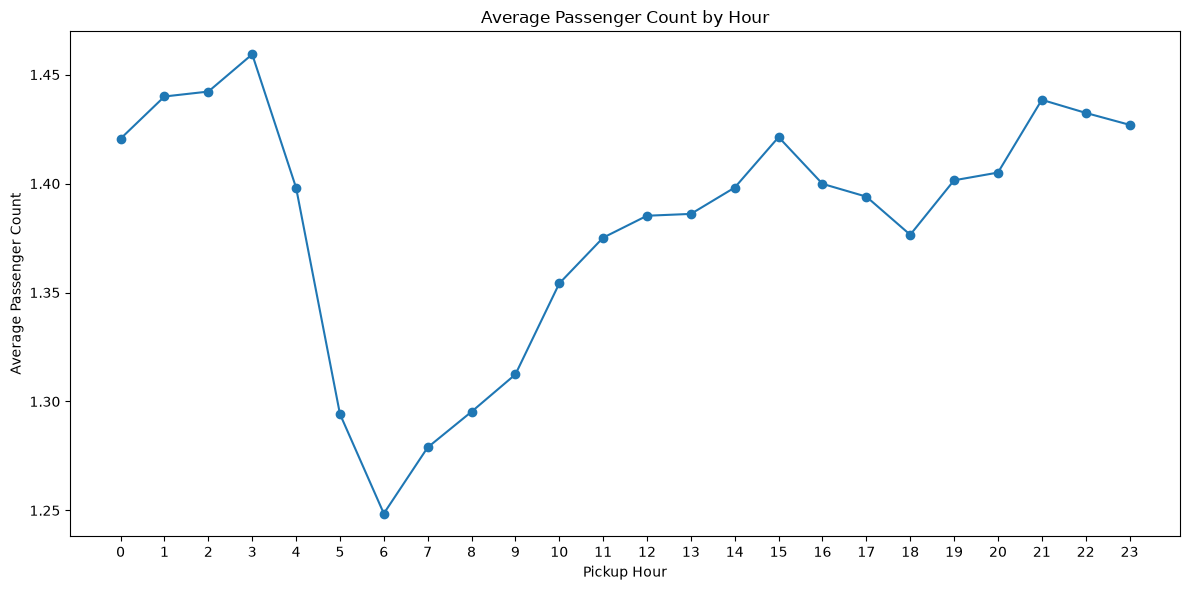

In [120]:
# See how passenger count varies across hours and days
# by Hour
passenger_by_hour = (
    df.groupby('pickup_hour')
      ['passenger_count']
      .mean()
)

print(passenger_by_hour)

# By Day

passenger_by_day = (
    df.groupby('day_of_week')
      ['passenger_count']
      .mean()
      .reindex(day_order)
)

print(passenger_by_day)

plt.figure(figsize=(12, 6))

plt.plot(
    passenger_by_hour.index,
    passenger_by_hour.values,
    marker='o'
)

plt.xlabel('Pickup Hour')
plt.ylabel('Average Passenger Count')
plt.title('Average Passenger Count by Hour')

plt.xticks(range(24))
plt.tight_layout()
plt.savefig('average-passenger-count-by-hour.png')
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [121]:
# How does passenger count vary across zones
passenger_by_zone = (
    df.groupby('PULocationID')
      ['passenger_count']
      .agg(
          average_passenger_count='mean',
          trip_count='size'
      )
      .reset_index()
)

passenger_by_zone = passenger_by_zone.sort_values(
    'average_passenger_count',
    ascending=False
)

print(
    passenger_by_zone.head(20)
)


     PULocationID  average_passenger_count  trip_count
105           128                 3.000000           1
222           259                 2.500000           2
127           150                 2.500000           2
101           123                 2.500000           2
25             34                 2.500000           2
166           195                 2.090909          33
0               1                 2.028571          35
163           191                 2.000000           3
2               6                 2.000000           6
56             67                 2.000000           1
48             58                 2.000000           2
111           134                 1.833333          18
28             37                 1.818182          11
55             66                 1.796875          64
71             82                 1.791667          24
51             62                 1.750000           4
102           124                 1.714286           7
8         

     LocationID                     zone        borough  \
127         128         Inwood Hill Park      Manhattan   
122         123                Homecrest       Brooklyn   
33           34       Brooklyn Navy Yard       Brooklyn   
258         259       Woodlawn/Wakefield          Bronx   
149         150          Manhattan Beach       Brooklyn   
194         195                 Red Hook       Brooklyn   
0             1           Newark Airport            EWR   
66           67            Dyker Heights       Brooklyn   
57           58             Country Club          Bronx   
190         191           Queens Village         Queens   
5             6  Arrochar/Fort Wadsworth  Staten Island   
133         134              Kew Gardens         Queens   
36           37           Bushwick South       Brooklyn   
65           66       DUMBO/Vinegar Hill       Brooklyn   
81           82                 Elmhurst         Queens   
61           62      Crown Heights South       Brooklyn 

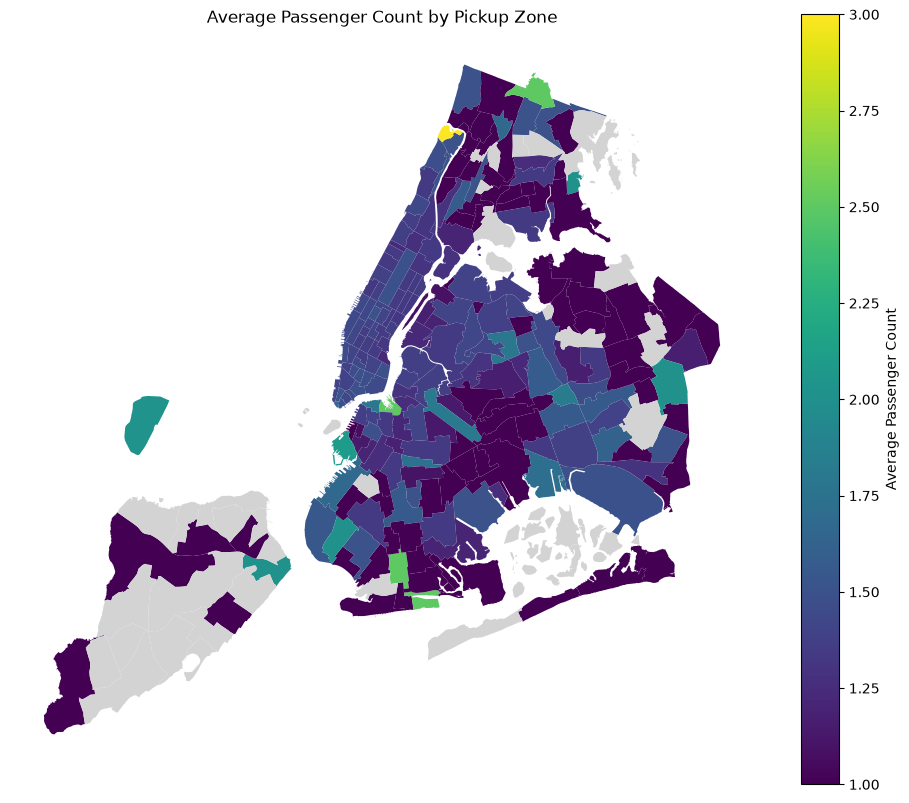

In [122]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zones_with_passengers = zones.merge(
    passenger_by_zone,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

print(
    zones_with_passengers[
        [
            'LocationID',
            'zone',
            'borough',
            'average_passenger_count',
            'trip_count'
        ]
    ].sort_values(
        'average_passenger_count',
        ascending=False
    ).head(20)
)

# MAP
fig, ax = plt.subplots(
    1,
    1,
    figsize=(12, 10)
)

zones_with_passengers.plot(
    column='average_passenger_count',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Average Passenger Count',
        'orientation': 'vertical'
    },
    missing_kwds={
        'color': 'lightgrey'
    }
)

ax.set_title(
    'Average Passenger Count by Pickup Zone'
)

ax.set_axis_off()
plt.savefig('average-passenger-count-by-pickup-zone.png')
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

#Using these fields we will be calculating the Surcharges
extra
mta_tax
tolls_amount
improvement_surcharge
congestion_surcharge
airport_fee

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

               Surcharge  Applied Trips  Percentage of Trips
0                  extra         179233                62.22
1                mta_tax         285346                99.06
2           tolls_amount          22886                 7.94
3  improvement_surcharge         287950                99.96
4   congestion_surcharge         267396                92.83
5            airport_fee          25446                 8.83


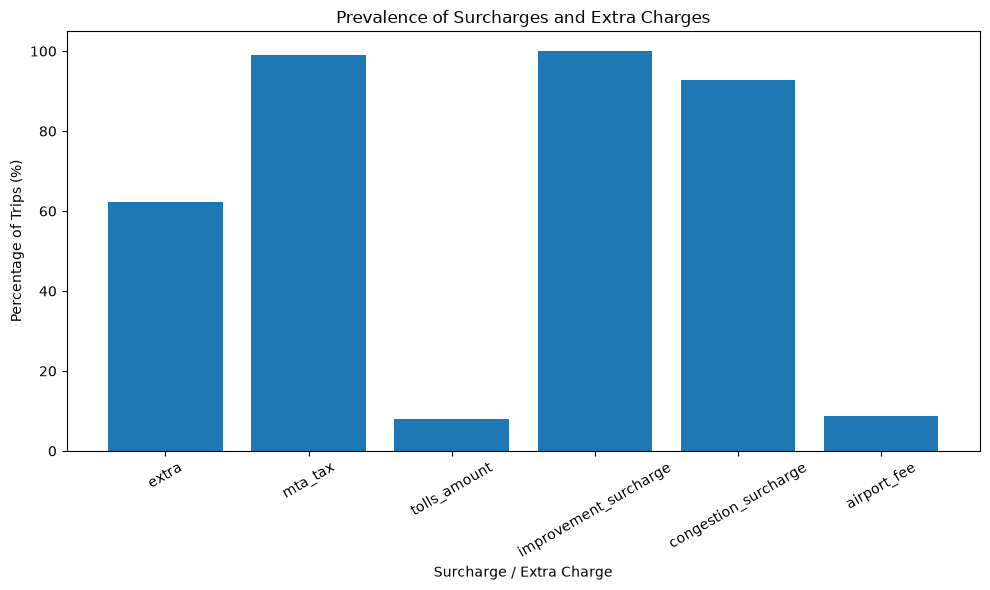

In [123]:
# How often is each surcharge applied?
# The easiest way is to count records where the charge is greater than zero
surcharge_columns = [
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee'
]

surcharge_summary = []

for col in surcharge_columns:

    applied_count = (
        df[col] > 0
    ).sum()

    total_count = len(df)

    percentage = (
        applied_count / total_count
    ) * 100

    surcharge_summary.append({
        'Surcharge': col,
        'Applied Trips': applied_count,
        'Percentage of Trips': percentage
    })

surcharge_summary = pd.DataFrame(
    surcharge_summary
)

surcharge_summary[
    'Percentage of Trips'
] = surcharge_summary[
    'Percentage of Trips'
].round(2)

print(surcharge_summary)

plt.figure(figsize=(10, 6))

plt.bar(
    surcharge_summary['Surcharge'],
    surcharge_summary['Percentage of Trips']
)

plt.xlabel('Surcharge / Extra Charge')
plt.ylabel('Percentage of Trips (%)')
plt.title('Prevalence of Surcharges and Extra Charges')

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prevalence-of-surcharges-and-extra-charges.png')
plt.show()



Calculating zones/times have more surcharge activity.

In [124]:
#For example, congestion_surcharge:

congestion_by_hour = (
    df.groupby('pickup_hour')
      ['congestion_surcharge']
      .apply(lambda x: (x > 0).mean() * 100)
)

print(congestion_by_hour)

congestion_by_zone = (
    df.groupby('PULocationID')
      ['congestion_surcharge']
      .apply(lambda x: (x > 0).mean() * 100)
      .sort_values(ascending=False)
)

print(
    congestion_by_zone.head(10)
)

pickup_hour
0     90.807632
1     92.523020
2     94.472222
3     93.501326
4     90.625000
5     83.565275
6     86.837965
7     91.611537
8     92.879865
9     93.283088
10    93.517139
11    93.741384
12    93.830204
13    93.338268
14    93.165938
15    92.322998
16    92.502499
17    93.524628
18    94.065934
19    93.322838
20    93.323442
21    92.947459
22    92.273848
23    89.992335
Name: congestion_surcharge, dtype: float64
PULocationID
11     100.000000
101    100.000000
73     100.000000
224    100.000000
250    100.000000
141     99.793966
237     99.789672
137     99.742683
140     99.730942
114     99.716641
Name: congestion_surcharge, dtype: float64


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

The analysis of trip volume across hours, days of the week, and pickup/drop-off zones shows that taxi demand is not evenly distributed throughout the day. Demand is concentrated in specific time periods and locations, while other periods have relatively lower activity.

The analysis identified <b>Busiest hour: 18:00 </b>as the busiest hour, with approximately <b>Sampled trips during busiest hour: 20,475</b> in the sampled dataset. The weekday and weekend analysis also showed different demand patterns, indicating that dispatching strategies should be adapted according to the type of day.

The route-speed analysis further identified routes with lower average speeds during specific hours. These routes can indicate congestion or operational inefficiencies.

**Recommendations**
<ul>
<ol><b>Dynamic dispatching during peak hours</b>
More cabs should be made available during the identified peak hours, particularly around [PEAK HOURS], to reduce passenger waiting times.</ol>
<ol><b>Use route-level speed information</b>
Routes with consistently low average speeds should be monitored during the relevant hours. Drivers can be provided with alternative routes where possible to reduce travel time.</ol>
<ol><b>Separate weekday and weekend strategies</b>
Since weekday and weekend demand patterns differ, dispatching schedules should not use a single fixed pattern for all days.</ol>
<ol><b>Predictive repositioning</b>
Historical pickup patterns can be used to predict where demand is likely to increase in the next hour. Cabs can be repositioned before demand peaks rather than waiting until requests increase.</ol>
<ol><b>Reduce idle time during low-demand periods</b>
During quieter hours, unnecessary cab concentration in low-demand areas should be avoided. Vehicles can instead be repositioned toward zones with historically higher demand.</ol>
</ul>
Overall, combining hour, day, location and route-speed information can help improve vehicle utilization and reduce passenger waiting time.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

The geographical analysis identified significant differences in pickup and drop-off activity across NYC taxi zones. The top pickup zones were 132,237 and 161 etc., while the top drop-off zones were 236,237 and 161.

The pickup/drop-off ratio also provides useful information about the movement of taxis. Zones with a high pickup-to-drop-off ratio experience more departures than arrivals, while zones with a low ratio experience relatively more drop-offs.

**Recommendations**
<ul>
<ol><b>Position vehicles near high-demand pickup zones</b>
A greater proportion of available cabs should be positioned near the zones consistently showing high pickup demand.</ol>
<ol><b>Use time-specific positioning</b>
The same zones should not necessarily receive the same number of vehicles throughout the day. Positioning should follow the hourly demand pattern.</ol>
<ol><b>Use pickup/drop-off imbalance</b>
Zones with substantially more drop-offs than pickups may experience a shortage of available taxis after passengers leave. Vehicles should be repositioned into such areas when demand is expected to increase.</ol>
<ol><b>Night-time positioning</b>
The separate night-time analysis should be used to identify zones with high demand between 11 PM and 5 AM. These zones should receive sufficient vehicle availability during these hours rather than relying on the overall daily ranking.</ol>
<ol><b>Weekday vs weekend positioning</b>
Weekday commuting patterns and weekend travel patterns should be treated separately. Vehicle allocation can therefore be adjusted according to the expected demand profile for each day type.</ol>
<ol><b>Use historical demand forecasting</b>
The company's dispatch system can use historical trip data to estimate expected demand for each zone and hour and proactively move available taxis accordingly.</ol>
</ul>
A zone-based dispatch strategy using <b>location + hour + day type + historical demand </b> would allow the fleet to be positioned closer to expected passengers and reduce unnecessary empty travel.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

The financial analysis showed that fare varies with factors such as<b> trip distance, trip duration, passenger count, time of day and vendor. </b> The fare-per-mile analysis across distance tiers also provides a basis for comparing pricing patterns.

The analysis of<b> Creative Mobile Technologies,LLC and VeriFone Inc. </b>showed differences in average fare per mile across the three distance categories:

Up to 2 miles
2–5 miles
More than 5 miles

The analysis should be used to identify situations where the company's pricing is substantially different from observed market/vendor rates.

**Recommendations**
<ul>
<ol><b>Use distance-based pricing analysis</b>
Monitor average fare per mile separately for short, medium and long trips rather than using one overall fare-per-mile measure.</ol>
<ol><b>Review short-distance pricing</b>
Short trips can have a relatively high fare per mile because fixed charges form a larger proportion of the total fare. Pricing should remain competitive while ensuring that operating costs are covered.</ol>
<ol><b>Consider time-based demand patterns</b>
If the analysis shows substantially higher demand during particular hours, pricing and fleet availability can be coordinated during those periods. Any dynamic pricing mechanism should be transparent and compliant with applicable regulations.</ol>
<ol><b>Monitor competitor/vendor differences</b>
The vendor-level analysis should be used as a benchmark. If another vendor consistently shows a lower average fare per mile for a particular distance tier, pricing for that segment should be reviewed rather than applying a blanket price increase.</ol>

<ol><b>Differentiate by distance tier</b>
The analysis of:

0–2 miles
2–5 miles
5+ miles

can be used to identify where pricing is relatively high or low and where adjustments may be appropriate.
</ol>
<ol><b>Consider customer experience</b>
Pricing should not be optimized only for revenue. The tip analysis indicates that customer behavior varies with trip characteristics. Excessive pricing could potentially affect customer satisfaction and repeat usage, so pricing decisions should be evaluated together with demand and customer behavior.</ol>
<ol><b>Use an iterative pricing model</b>
Rather than making permanent changes based on historical averages, pricing can be evaluated using demand, trip distance, time, zone and competitor benchmarks and then monitored after implementation.</ol>
</ul>

*****  END *****